# Klasyfikacja obrazów ubrań z użyciem sieci neuronowej

Celem projektu jest zbudowanie modelu sieci neuronowej, który rozpoznaje typ ubrania na podstawie obrazu 28×28 pikseli ze zbioru Fashion-MNIST.

In [1]:
# Biblioteki do obliczeń
import numpy as np
import pandas as pd

# Biblioteki do wykresów
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras do budowy sieci neuronowych
import tensorflow as tf
from tensorflow import keras

# Podział danych na treningowe i walidacyjne
from sklearn.model_selection import train_test_split

# Metryki do ewaluacji modelu
from sklearn.metrics import confusion_matrix, classification_report

#import danych
from tensorflow.keras.datasets import fashion_mnist

# Wczytanie danych

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
#rozmiar obrazu 28x28 w train i test
#wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu

X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


# Nazwy klas

In [3]:
#zamiana numerów klas na nazwy klas (w zbiorze defaultowo klasy opisane są jako numery)
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"

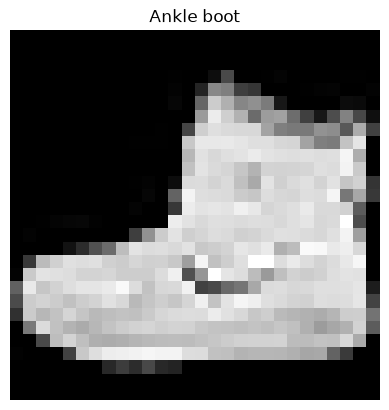

In [4]:
#pobiera pierwszy obraz ze zbioru treningowego, pokazuje go w skali szarości (rysowanie)
plt.imshow(X_train[0], cmap="gray")
#tytuł wykresu
plt.title(class_names[y_train[0]])
#wyłącza osie wykresu
plt.axis("off")
#Publikacja
plt.show()

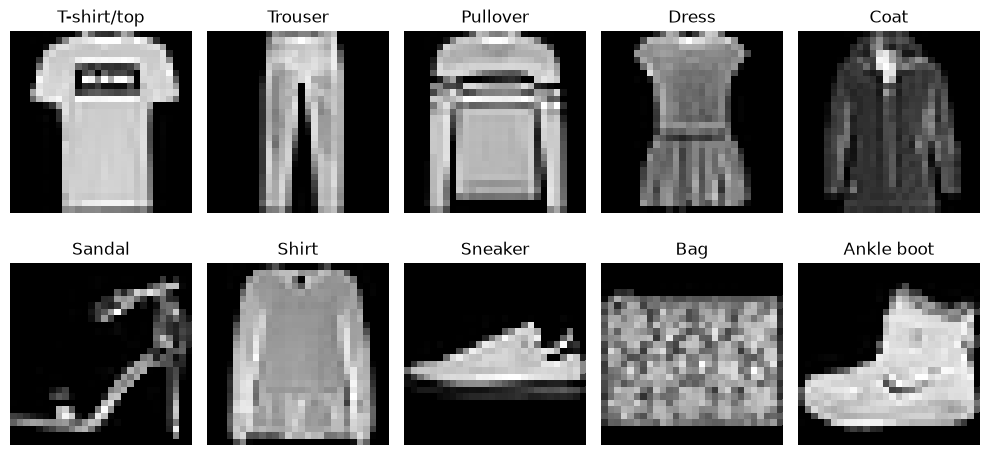

In [5]:
#Przykładowe obrazy z każdej klasy
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for label in range(10):
    idx = np.where(y_train == label)[0][0]

    plt.subplot(2,5,label+1)
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()

plt.savefig("klasy_fashion_mnist.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Zakres wartości pikseli

In [6]:
print("Minimalna wartość piksela:", X_train.min())
print("Maksymalna wartość piksela:", X_train.max())

Minimalna wartość piksela: 0
Maksymalna wartość piksela: 255


# Czy zbiór zawiera brakujące dane

In [7]:
import numpy as np

print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


# Rozkład klas

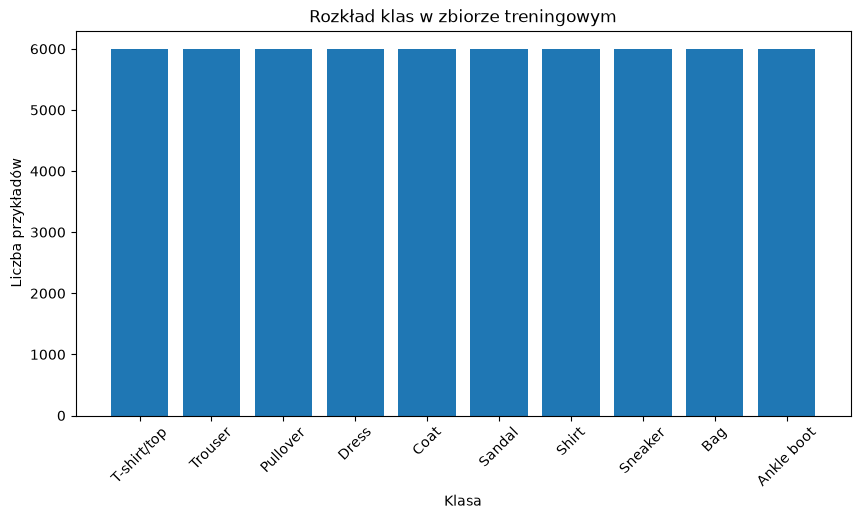

In [8]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts)
plt.xticks(rotation=45)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba przykładów")
plt.show()

# Jak wygląda średni obraz z klasy (przykład na podstawie klasy T-shirt)

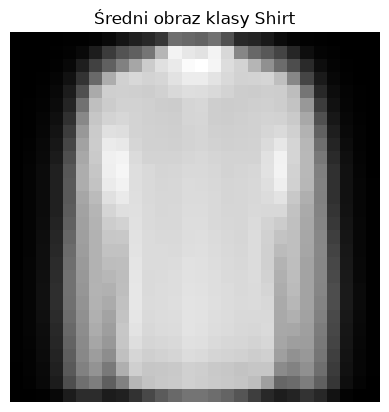

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#idx = np.where(y_train == 0)
#idx = np.where(y_train == 4)
idx = np.where(y_train == 6)

mean_image = X_train[idx].mean(axis=0)

plt.imshow(mean_image, cmap="gray")
plt.title("Średni obraz klasy Shirt")
plt.axis("off")
plt.show()

Zbiór Fashion-MNIST zawiera obrazy ubrań w skali szarości o wymiarach 28×28 pikseli. 
Dane są podzielone na 60 000 przykładów treningowych oraz 10 000 przykładów testowych. Wydzielenie zbioru walidacyjnego zostanie wykonane w II części projektu.

Każdy obraz należy do jednej z 10 klas, takich jak koszulka, spodnie, sukienka, but, torba lub płaszcz. 
Wartości pikseli mieszczą się w zakresie od 0 do 255. Nie występują braki w danych.

Na podstawie rozkładu klas można zauważyć, że zbiór jest zbalansowany, ponieważ każda klasa ma podobną liczbę przykładów.

# USTAWIENIE LOSOWOŚCI

In [10]:
# Ustawiamy ziarno losowości, żeby wyniki były bardziej powtarzalne.
# Dzięki temu przy ponownym uruchomieniu notebooka wyniki powinny być podobne.

np.random.seed(42)
tf.random.set_seed(42)

# NORMALIZACJA DANYCH

In [11]:
# Obrazy w Fashion-MNIST mają wartości pikseli od 0 do 255.
# Sieci neuronowe zwykle uczą się lepiej, gdy dane wejściowe są w mniejszym zakresie.
# Dlatego dzielimy wartości pikseli przez 255, aby otrzymać zakres od 0 do 1.

X_train = X_train / 255.0
X_test = X_test / 255.0

# PODZIAŁ NA TRAIN I VALIDATION

In [12]:
# Oryginalny zbiór treningowy ma 60 000 obrazów.
# Dzielimy go na:
# - zbiór treningowy właściwy: do uczenia modelu,
# - zbiór walidacyjny: do porównywania modeli i doboru hiperparametrów.
#
# Zbiór testowy zostawiamy nietknięty do samego końca.

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,        # 20% danych idzie na walidację
    random_state=42,      # powtarzalny podział
    stratify=y_train      # zachowuje proporcje klas w train i validation
)

# SPRAWDZENIE ROZMIARÓW ZBIORÓW

In [13]:
# Sprawdzamy, czy podział danych przebiegł poprawnie.

print("Zbiór treningowy:", X_train_part.shape)
print("Zbiór walidacyjny:", X_val.shape)
print("Zbiór testowy:", X_test.shape)

Zbiór treningowy: (48000, 28, 28)
Zbiór walidacyjny: (12000, 28, 28)
Zbiór testowy: (10000, 28, 28)


# PRZYGOTOWANIE DANYCH DLA CNN

In [14]:
# Modele MLP (Multi-Layer Perceptron) mogą przyjmować dane w formacie:
# (liczba_obrazów, 28, 28)
# Tutaj obraz jest najpierw spłaszczany, czyli model widzi obraz jako
# jedną długą listę 784 liczb.
#
# Modele CNN potrzebują dodatkowego wymiaru kanału:
# (liczba_obrazów, 28, 28, 1)
#
# Liczba 1 oznacza, że obraz jest w skali szarości.

X_train_cnn = X_train_part.reshape(-1, 28, 28, 1)
X_val_cnn = X_val.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)
# Wartość -1 oznacza automatyczne wyliczenie liczby obrazów
# na podstawie pozostałych wymiarów. Dzięki temu nie trzeba
# ręcznie podawać liczby przykładów dla każdego zbioru.

print("CNN train:", X_train_cnn.shape)
print("CNN validation:", X_val_cnn.shape)
print("CNN test:", X_test_cnn.shape)

CNN train: (48000, 28, 28, 1)
CNN validation: (12000, 28, 28, 1)
CNN test: (10000, 28, 28, 1)


# FUNKCJE POMOCNICZE
## Funkcja trenowania modelu

In [15]:
def compile_and_train(
    model,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    model_name,
    epochs=20,
    batch_size=32, # 32 daje stabilność uczenia + rozsądne zużycie pamięci + dobra szybkość treningu (najczęściej używana wartość dla małych zbiorów)
    learning_rate=0.001, #domyślna wartość w Kerasie, Adam najczęściej najlepiej działa przy takim learning rate
    optimizer_name="adam"
):
    """
    Funkcja kompiluje i trenuje model.

    Parametry:
    - model: model Keras,
    - X_train_data, y_train_data: dane treningowe,
    - X_val_data, y_val_data: dane walidacyjne,
    - model_name: nazwa modelu,
    - epochs: maksymalna liczba epok,
    - batch_size: liczba przykładów w jednej paczce,
    - learning_rate: szybkość uczenia,
    - optimizer_name: nazwa optymalizatora.
    """

    print("=" * 60)
    print(f"Trenowanie modelu: {model_name}")
    print("=" * 60)

# We wszystkich eksperymentach zastosowano EarlyStopping.
# Pozwala on automatycznie zakończyć trening, gdy wynik funkcji 
# straty na zbiorze walidacyjnym (val_loss) przestaje się poprawiać.
# Ogranicza to ryzyko przeuczenia modeli oraz skraca
# czas wykonywania licznych eksperymentów związanych z doborem
# architektury i hiperparametrów.
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3, #ile kolejnych epok czekamy na poprawę (najczęściej stosowane wartości 3-5)
        restore_best_weights=True
    )

    # Wybór optymalizatora.
    # Adam jest najczęściej dobrym wyborem startowym.
    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError("Nieznany optimizer. Użyj: adam, rmsprop albo sgd.")

    # Kompilacja modelu.
    # sparse_categorical_crossentropy stosujemy, ponieważ etykiety są liczbami 0-9,
    # a nie wektorami one-hot.
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Trenowanie modelu.
    history = model.fit(
        X_train_data,
        y_train_data,
        validation_data=(X_val_data, y_val_data),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1 #pokazuje postępy każdej epoki podczas uczenia
    )

    return history

## Funkcja do wykresów uczenia

In [16]:
def plot_learning_curves(history, title):
    """
    Funkcja rysuje krzywe uczenia:
    - accuracy dla zbioru treningowego i walidacyjnego,
    - loss dla zbioru treningowego i walidacyjnego.
    """

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - accuracy")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} - loss")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Funkcja do zapisywania wyników

In [17]:
# Tworzymy pustą listę, do której będziemy zapisywać wyniki modeli.
results = []

def save_result(model_name, history):
    """
    Funkcja zapisuje najlepsze wyniki walidacyjne modelu.
    """

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    results.append({
        "Model": model_name,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

# BASELINE

In [18]:
# Model baseline to najprostszy model referencyjny.
# Nie ma warstw ukrytych.
# Obraz 28x28 zostaje spłaszczony do wektora 784 wartości,
# a następnie od razu klasyfikowany do jednej z 10 klas.

baseline_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), #warstwa dense oczekuje danych w postaci wektora (czyli zamieniamy na 28x28=784
    keras.layers.Dense(10, activation="softmax") #10 neuronów na wyjściu, ponieważ mamy 10 klas, Softmax by otrzymać prawdopodobieństwo dla każdej klasy
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: Baseline
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7875 - loss: 0.6303 - val_accuracy: 0.8378 - val_loss: 0.4793
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8372 - loss: 0.4769 - val_accuracy: 0.8478 - val_loss: 0.4401
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8469 - loss: 0.4474 - val_accuracy: 0.8523 - val_loss: 0.4243
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8518 - loss: 0.4316 - val_accuracy: 0.8555 - val_loss: 0.4160
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8544 - loss: 0.4212 - val_accuracy: 0.8562 - val_loss: 0.4110
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8568 - loss: 0.4136 - val_accuracy: 0.8575 - val_loss: 0.4079
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8585 - loss: 0.4078 - val_accuracy: 0.8594 - val_loss: 0.4058
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accura

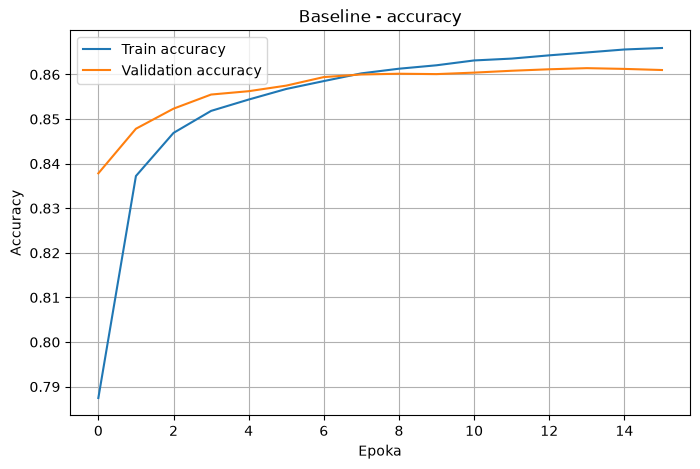

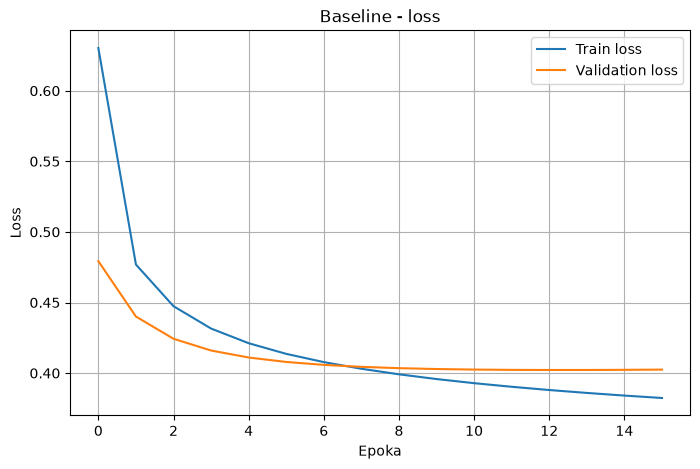

In [19]:
#Trenowanie modelu
history_baseline = compile_and_train(
    model=baseline_model,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="Baseline",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("Baseline", history_baseline)
plot_learning_curves(history_baseline, "Baseline")

# BASELINE - WNIOSKI

Model Baseline osiągnął najlepszą dokładność walidacyjną na poziomie około 86,1% oraz val_loss około 0,4022.

Największy wzrost jakości nastąpił w pierwszych kilku epokach. Już po 1. epoce model osiągnął 83,8% val_accuracy, a następnie stopniowo poprawiał wynik do około 86%.

Po około 9–10 epokach poprawa stała się już bardzo niewielka. Accuracy walidacyjne utrzymywało się w okolicach 86%, a val_loss praktycznie przestał spadać.

Różnica między wynikiem treningowym a walidacyjnym była mała: pod koniec treningu train accuracy wynosiło około 86,6%, a val_accuracy około 86,1%. To oznacza, że model nie wykazywał silnego przeuczenia.

Jednocześnie model Baseline ma bardzo prostą strukturę: Flatten → Dense(10, softmax). Nie posiada warstw ukrytych ani konwolucyjnych, więc nie potrafi samodzielnie wykrywać bardziej złożonych cech obrazu, takich jak kontury czy kształty.

# MLP 128

In [20]:
# MLP, czyli Multi-Layer Perceptron, to klasyczna sieć gęsta.
# Tutaj dodajemy jedną warstwę ukrytą z 128 neuronami.
# Funkcja ReLU pozwala modelowi uczyć się nieliniowych zależności.

mlp_128 = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),#warstwa ukryta, dobrana eksperymentalnie, relu wprowadza nieliniowość, może uczyć się bardziej złożonych wzorców
    keras.layers.Dense(10, activation="softmax")
])

mlp_128.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP 128
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8166 - loss: 0.5204 - val_accuracy: 0.8455 - val_loss: 0.4250
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8605 - loss: 0.3866 - val_accuracy: 0.8637 - val_loss: 0.3741
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8733 - loss: 0.3467 - val_accuracy: 0.8748 - val_loss: 0.3473
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8821 - loss: 0.3206 - val_accuracy: 0.8782 - val_loss: 0.3377
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8903 - loss: 0.2993 - val_accuracy: 0.8798 - val_loss: 0.3331
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8962 - loss: 0.2825 - val_accuracy: 0.8828 - val_loss: 0.3269
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9004 - loss: 0.2680 - val_accuracy: 0.8823 - val_loss: 0.3234
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accurac

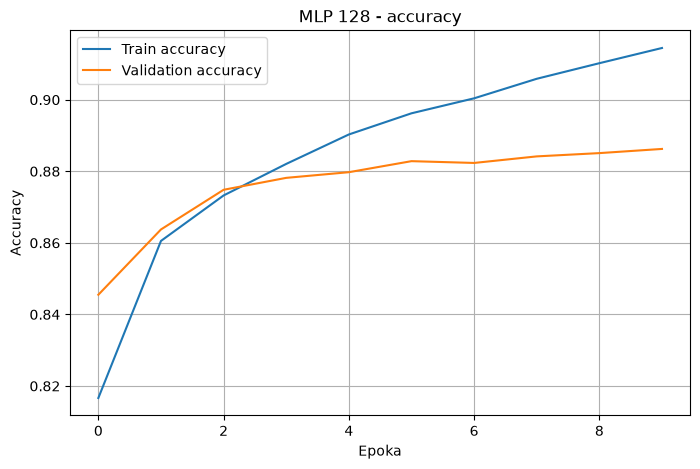

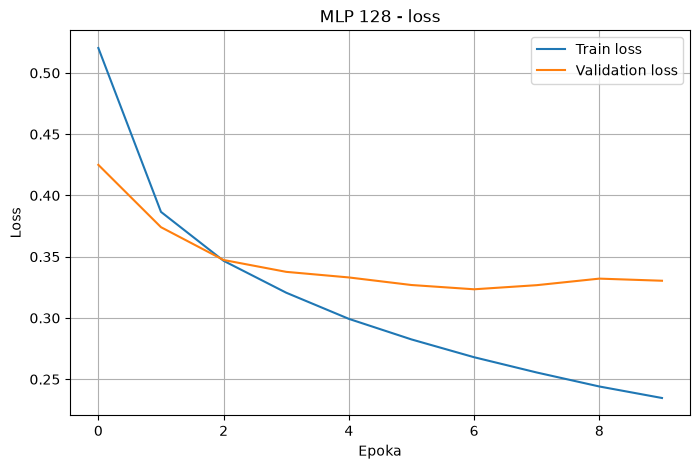

In [21]:
# Trenowanie modelu
history_mlp_128 = compile_and_train(
    model=mlp_128,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP 128",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP 128", history_mlp_128)
plot_learning_curves(history_mlp_128, "MLP 128")

# WNIOSKI - MLP 128

Model MLP 128 osiągnął najlepszą dokładność walidacyjną na poziomie około 88,6% oraz validation loss = 0,3234, wyraźnie przewyższając model Baseline.

Dodanie jednej warstwy ukrytej z 128 neuronami pozwoliło modelowi nauczyć się bardziej złożonych zależności między pikselami obrazu. Już od pierwszych epok obserwowano szybki wzrost dokładności oraz systematyczny spadek wartości funkcji straty.

Największa poprawa jakości klasyfikacji nastąpiła w pierwszych 5–6 epokach. W kolejnych epokach accuracy na zbiorze treningowym nadal rosło (do około 91,5%), natomiast poprawa na zbiorze walidacyjnym była już niewielka.

Pod koniec treningu zaczęła zwiększać się różnica pomiędzy wynikami treningowymi i walidacyjnymi. Train accuracy wzrosło do około 91,4%, podczas gdy val_accuracy osiągnęło około 88,6%, a validation loss po 7. epoce zaczął ponownie rosnąć. Świadczy to o pojawieniu się pierwszych oznak przeuczenia.

# MLP DEEP

In [22]:
# Ten model jest głębszy od poprzedniego MLP.
# Ma dwie warstwy ukryte: 256 i 128 neuronów.
# Sprawdzamy, czy większa liczba warstw i parametrów poprawi wynik.

mlp_deep = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

mlp_deep.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: MLP Deep
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8195 - loss: 0.4996 - val_accuracy: 0.8481 - val_loss: 0.4121
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8641 - loss: 0.3684 - val_accuracy: 0.8738 - val_loss: 0.3488
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8768 - loss: 0.3313 - val_accuracy: 0.8791 - val_loss: 0.3349
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8860 - loss: 0.3049 - val_accuracy: 0.8814 - val_loss: 0.3308
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8940 - loss: 0.2834 - val_accuracy: 0.8835 - val_loss: 0.3292
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9005 - loss: 0.2669 - val_accuracy: 0.8848 - val_loss: 0.3417
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9038 - loss: 0.2537 - val_accuracy: 0.8780 - val_loss: 0.3638
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accura

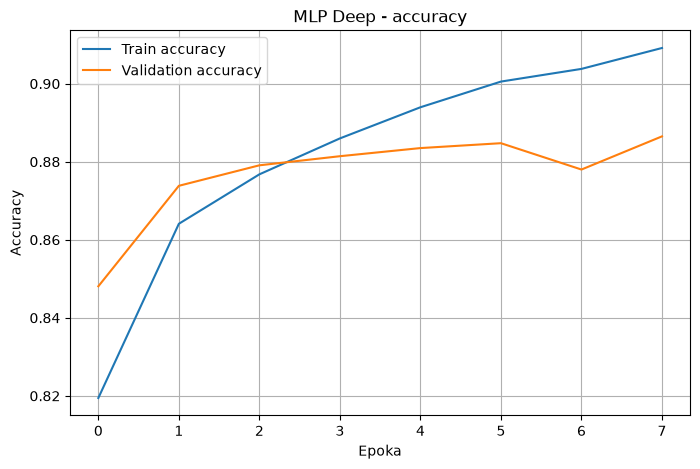

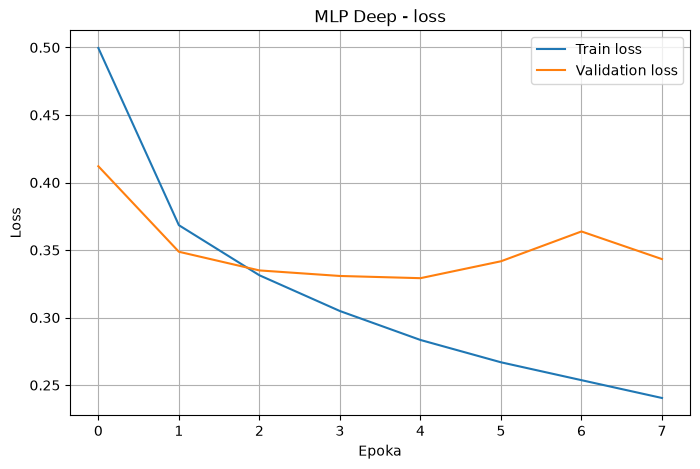

In [23]:
# Trenowanie modelu
history_mlp_deep = compile_and_train(
    model=mlp_deep,
    X_train_data=X_train_part,
    y_train_data=y_train_part,
    X_val_data=X_val,
    y_val_data=y_val,
    model_name="MLP Deep",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("MLP Deep", history_mlp_deep)
plot_learning_curves(history_mlp_deep, "MLP Deep")

# WNIOSKI - MLP DEEP

Model MLP Deep osiągnął najlepszą dokładność walidacyjną na poziomie około 88,7% oraz validation loss = 0,3292. Wynik ten był bardzo zbliżony do modelu MLP 128, jednak uzyskano go przy bardziej rozbudowanej architekturze.

Dodanie drugiej warstwy ukrytej (256 → 128 neuronów) umożliwiło modelowi uczenie się bardziej złożonych reprezentacji danych. W pierwszych pięciu epokach obserwowano systematyczny wzrost dokładności oraz spadek wartości funkcji straty zarówno na zbiorze treningowym, jak i walidacyjnym.

Najlepszy wynik walidacyjny został osiągnięty w 5. epoce. W kolejnych epokach accuracy na zbiorze treningowym nadal rosło (do około 90,9%), natomiast validation accuracy przestało się poprawiać, a validation loss zaczął wyraźnie wzrastać. Jest to typowy sygnał rozpoczęcia przeuczenia modelu.

W porównaniu z modelem MLP 128 zastosowanie dodatkowej warstwy ukrytej nie przyniosło istotnej poprawy skuteczności klasyfikacji. Oznacza to, że większa złożoność modelu nie przełożyła się na lepszą zdolność uogólniania dla zbioru Fashion-MNIST.

# CNN

In [24]:
# CNN, czyli Convolutional Neural Network, jest lepiej dopasowana do obrazów.
# Warstwy Conv2D uczą się lokalnych wzorców, np. krawędzi, konturów i kształtów.
# MaxPooling zmniejsza rozmiar reprezentacji i zostawia najważniejsze cechy. (2,2 jest używane najczęściej)

cnn_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"), #32 filtry o rozmiarze 3x3 (dobrane eksperymentalnie aby były nie za małe i nie za duże)
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"), #więcej filtrów, by uczył się bardziej zaawansowanych cech
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"), #zadaniem tej warstwy jest łączenie cech wykrytych przez conv2D
    keras.layers.Dense(10, activation="softmax") #Warstwa wyjściowa. Zadaniem tej jest już przypisanie do klas, ta już się nie uczy
])

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8246 - loss: 0.4828 - val_accuracy: 0.8658 - val_loss: 0.3717
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8839 - loss: 0.3181 - val_accuracy: 0.8872 - val_loss: 0.3138
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9023 - loss: 0.2667 - val_accuracy: 0.8942 - val_loss: 0.2923
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9151 - loss: 0.2297 - val_accuracy: 0.9004 - val_loss: 0.2741
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9265 - loss: 0.1994 - val_accuracy: 0.9037 - val_loss: 0.2769
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9374 - loss: 0.1714 - val_accuracy: 0.9066 - val_loss: 0.2815
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9459 - loss: 0.1486 - val_accuracy: 0.9067 - val_loss: 0.2928


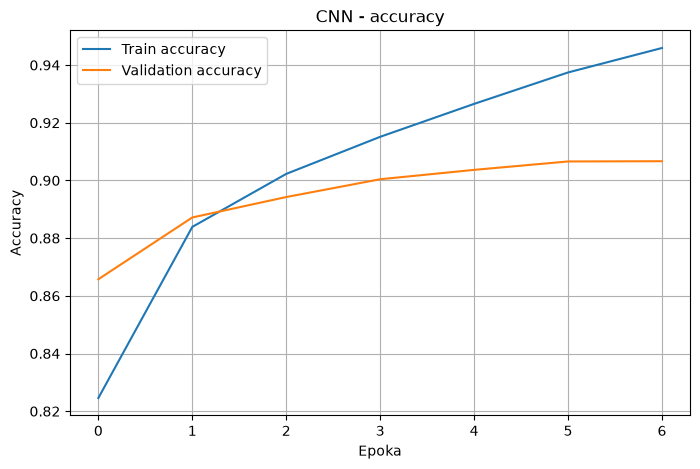

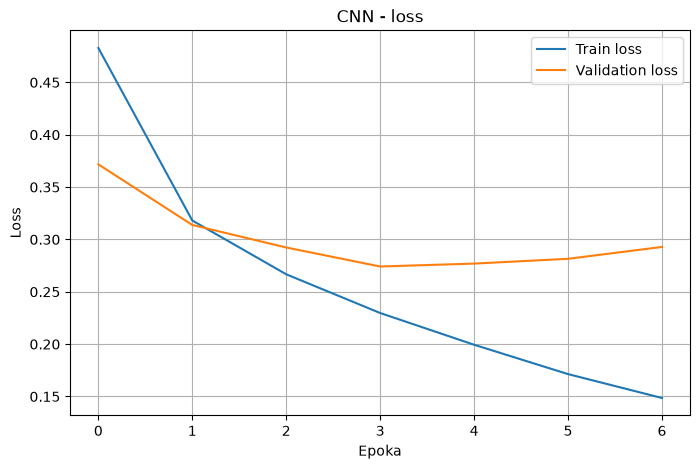

In [25]:
#Trenowanie modelu
history_cnn = compile_and_train(
    model=cnn_model,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN", history_cnn)
plot_learning_curves(history_cnn, "CNN")

# WNIOSKI - CNN

Model CNN osiągnął najlepszą dokładność walidacyjną na poziomie około 90,7% oraz validation loss = 0,2741, wyraźnie przewyższając oba modele MLP.

Zastosowanie warstw konwolucyjnych umożliwiło modelowi automatyczne wykrywanie lokalnych cech obrazu, takich jak krawędzie, kontury i charakterystyczne elementy odzieży. Dzięki temu już od pierwszych epok model osiągał wyższą skuteczność klasyfikacji niż architektury MLP.

W pierwszych czterech epokach obserwowano systematyczny wzrost dokładności oraz spadek wartości funkcji straty zarówno na zbiorze treningowym, jak i walidacyjnym. Najlepszy wynik walidacyjny został osiągnięty w 4. epoce, po czym validation loss zaczął rosnąć, mimo że accuracy na zbiorze treningowym nadal wzrastało.

Pod koniec treningu train accuracy osiągnęło około 94,6%, natomiast val_accuracy utrzymywało się na poziomie około 90,7%. Rosnąca różnica pomiędzy wynikami treningowymi i walidacyjnymi oraz wzrost validation loss wskazują na pojawienie się przeuczenia modelu.

# CNN + DROPOUT

In [26]:
# Dropout to technika regularyzacji.
# Podczas treningu losowo wyłącza część neuronów.
# Dzięki temu model trudniej zapamiętuje dane treningowe i może lepiej generalizować.

cnn_dropout = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    #Dropout w tym miejscu, ponieważ w tej warstwie najczęściej występuje ryzyko przeuczenia (najcięższa warstwa całej sieci, ponieważ ma najwięcej parametrów).
    #Losowo wyłącza 30% neuronów. Umiarkowana wartość.
    keras.layers.Dropout(0.3),
    
    keras.layers.Dense(10, activation="softmax")
])

cnn_dropout.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN + Dropout
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8062 - loss: 0.5292 - val_accuracy: 0.8679 - val_loss: 0.3593
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8735 - loss: 0.3478 - val_accuracy: 0.8822 - val_loss: 0.3077
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8914 - loss: 0.2986 - val_accuracy: 0.8944 - val_loss: 0.2895
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9011 - loss: 0.2673 - val_accuracy: 0.9020 - val_loss: 0.2751
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9109 - loss: 0.2415 - val_accuracy: 0.9053 - val_loss: 0.2615
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9189 - loss: 0.2191 - val_accuracy: 0.9049 - val_loss: 0.2655
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9237 - loss: 0.2026 - val_accuracy: 0.9055 - val_loss: 0.2685
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - a

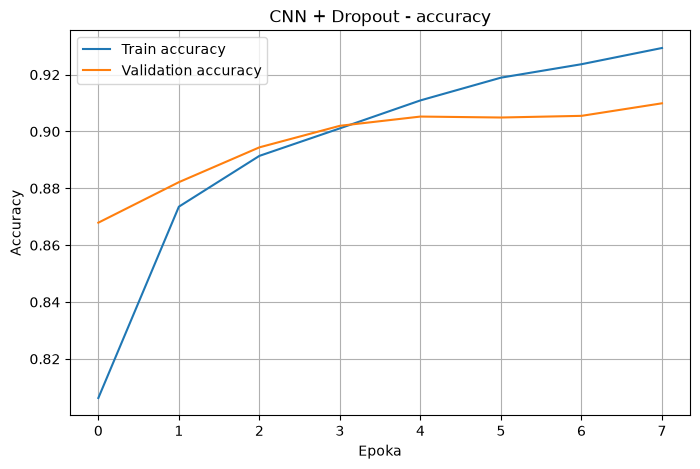

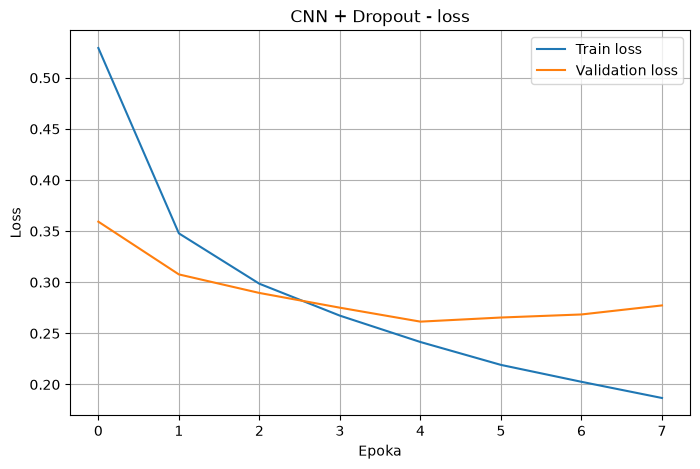

In [27]:
#Trenowanie modelu
history_cnn_dropout = compile_and_train(
    model=cnn_dropout,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Dropout",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Dropout", history_cnn_dropout)
plot_learning_curves(history_cnn_dropout, "CNN + Dropout")

# WNIOSKI + DROPOUT (0.3)

Model CNN + Dropout osiągnął najlepszą dokładność walidacyjną na poziomie około 91,0% oraz validation loss = 0,2615, uzyskując nieco lepsze wyniki niż podstawowy model CNN.

Dodanie warstwy Dropout (0.3) ograniczyło ryzyko przeuczenia poprzez losowe wyłączanie części neuronów podczas treningu. Dzięki temu model był zmuszony do uczenia się bardziej ogólnych zależności, co poprawiło jego zdolność uogólniania.

W pierwszych pięciu epokach obserwowano systematyczny wzrost dokładności oraz spadek wartości funkcji straty zarówno na zbiorze treningowym, jak i walidacyjnym. Najniższą wartość validation loss (0,2615) osiągnięto w 5. epoce, natomiast najwyższą validation accuracy (90,99%) uzyskano w 8. epoce.

Po 5. epoce accuracy na zbiorze treningowym nadal rosło (do około 92,9%), natomiast validation loss zaczął stopniowo wzrastać, co wskazuje na pojawienie się pierwszych oznak przeuczenia. Mimo tego validation accuracy utrzymywało się na wysokim poziomie, osiągając najlepszy wynik pod koniec treningu.

# TUNING DROPOUT

In [28]:
# Teraz sprawdzamy różne wartości Dropout.
#
# Dropout 0.2 oznacza słabszą regularyzację.
# Dropout 0.3 oznacza umiarkowaną regularyzację.
# Dropout 0.5 oznacza mocną regularyzację.
#
# Celem jest sprawdzenie, która wartość daje najlepszy wynik walidacyjny.

dropout_values = [0.2, 0.3, 0.5]

dropout_histories = {}
dropout_models = {}

In [29]:
#Trenowanie modelu
for dropout_rate in dropout_values:

    print(f"\nTest Dropout = {dropout_rate}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(dropout_rate),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN Dropout {dropout_rate}",
        epochs=20,
        batch_size=32,
        learning_rate=0.001,
        optimizer_name="adam"
    )

    dropout_histories[dropout_rate] = history
    dropout_models[dropout_rate] = model

    save_result(f"CNN Dropout {dropout_rate}", history)


Test Dropout = 0.2
Trenowanie modelu: CNN Dropout 0.2
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8130 - loss: 0.5159 - val_accuracy: 0.8673 - val_loss: 0.3563
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8767 - loss: 0.3413 - val_accuracy: 0.8833 - val_loss: 0.3139
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8933 - loss: 0.2910 - val_accuracy: 0.8916 - val_loss: 0.2948
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9042 - loss: 0.2585 - val_accuracy: 0.8997 - val_loss: 0.2756
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9137 - loss: 0.2317 - val_accuracy: 0.9057 - val_loss: 0.2649
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9208 - loss: 0.2100 - val_accuracy: 0.9043 - val_loss: 0.2815
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9297 - loss: 0.1873 - val_accuracy: 0.9090 - val_loss: 0.2705
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━

In [30]:
# Porównanie wyników dla różnych wartości Dropout.

for dropout_rate, history in dropout_histories.items():
    print(
        f"Dropout {dropout_rate}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Dropout 0.2: best val_accuracy = 0.9090, best val_loss = 0.2649
Dropout 0.3: best val_accuracy = 0.9142, best val_loss = 0.2602
Dropout 0.5: best val_accuracy = 0.9122, best val_loss = 0.2529


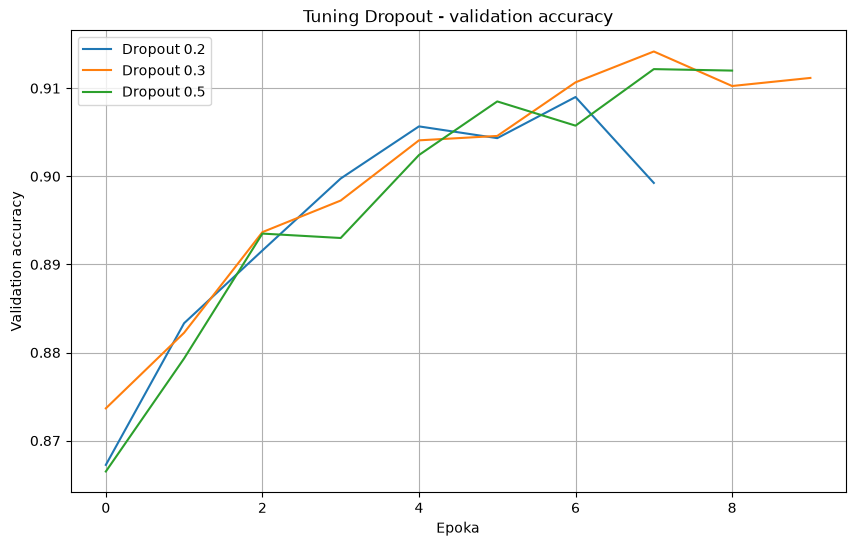

In [31]:
# Wykres porównujący krzywe walidacyjne dla różnych wartości Dropout.

plt.figure(figsize=(10, 6))

for dropout_rate, history in dropout_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"Dropout {dropout_rate}"
    )

plt.title("Tuning Dropout - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING DROPOUT

W ramach eksperymentu porównano trzy wartości współczynnika Dropout: 0.2, 0.3 oraz 0.5, aby określić ich wpływ na skuteczność klasyfikacji i zdolność uogólniania modelu.

Model z Dropout = 0.2 osiągnął najlepszą dokładność walidacyjną na poziomie około 90,9%. Po 5. epoce zaczęły pojawiać się oznaki przeuczenia – accuracy na zbiorze treningowym nadal rosło, natomiast validation loss zwiększał się, a validation accuracy zaczęło się wahać.

Model z Dropout = 0.3 uzyskał najwyższą dokładność walidacyjną spośród wszystkich testowanych konfiguracji (91,4%) przy validation loss = 0,2602. Proces uczenia przebiegał stabilnie, a oznaki przeuczenia pojawiły się dopiero pod koniec treningu. Wynik ten wskazuje, że wartość 0.3 zapewniła najlepszy kompromis pomiędzy skutecznością klasyfikacji a zdolnością generalizacji.

Model z Dropout = 0.5 uczył się wolniej, co było widoczne po niższej dokładności treningowej w pierwszych epokach. Mimo silniejszej regularyzacji osiągnął bardzo dobre wyniki walidacyjne (91,2%) oraz najniższą wartość validation loss (0,2529). Oznacza to, że wyższy poziom Dropout skuteczniej ograniczał przeuczenie, jednak nie przełożył się na najwyższą dokładność klasyfikacji.

# TUNING LEARNING RATE

In [32]:
# Learning rate określa, jak duże kroki wykonuje optimizer podczas aktualizacji wag.
#
# Zbyt duży learning rate może powodować niestabilne uczenie.
# Zbyt mały learning rate może sprawić, że model będzie uczył się bardzo wolno.
#
# Sprawdzamy kilka wartości learning rate:
# 0.01, 0.001, 0.0001, 0.0005

learning_rates = [0.01, 0.001, 0.0005, 0.0001]

lr_histories = {}
lr_models = {}

In [33]:
#Trening modelu
for lr in learning_rates:

    print(f"\nTest learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN LR {lr}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name="adam"
    )

    lr_histories[lr] = history
    lr_models[lr] = model

    save_result(f"CNN LR {lr}", history)


Test learning rate = 0.01
Trenowanie modelu: CNN LR 0.01
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8124 - loss: 0.5175 - val_accuracy: 0.8508 - val_loss: 0.4007
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8465 - loss: 0.4192 - val_accuracy: 0.8692 - val_loss: 0.3577
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8521 - loss: 0.3988 - val_accuracy: 0.8557 - val_loss: 0.3878
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8570 - loss: 0.3874 - val_accuracy: 0.8614 - val_loss: 0.3697
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8606 - loss: 0.3767 - val_accuracy: 0.8625 - val_loss: 0.3760

Test learning rate = 0.001
Trenowanie modelu: CNN LR 0.001
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8077 - loss: 0.5259 - val_accuracy: 0.8687 - val_loss: 0.3585
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8722 - loss: 0.3470 - val_accuracy

In [34]:
# Porównanie learning rate.

for lr, history in lr_histories.items():
    print(
        f"Learning rate {lr}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Learning rate 0.01: best val_accuracy = 0.8692, best val_loss = 0.3577
Learning rate 0.001: best val_accuracy = 0.9098, best val_loss = 0.2553
Learning rate 0.0005: best val_accuracy = 0.9131, best val_loss = 0.2536
Learning rate 0.0001: best val_accuracy = 0.9069, best val_loss = 0.2608


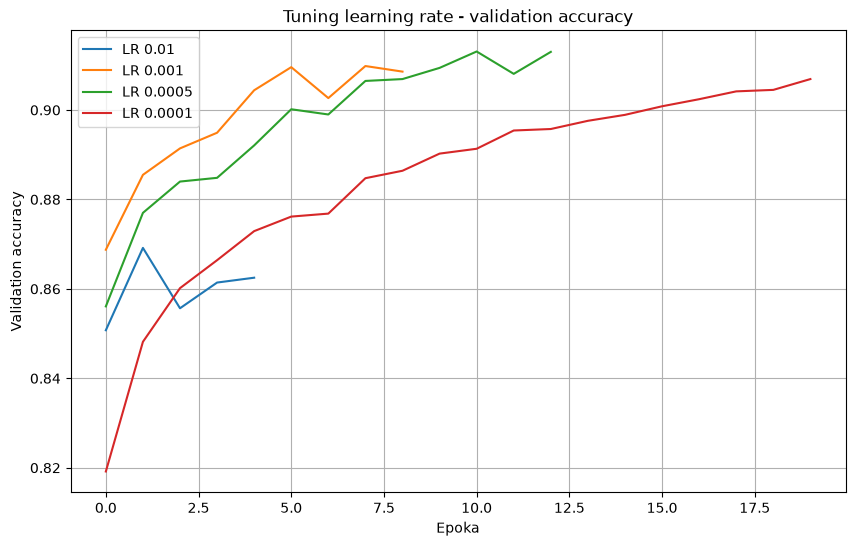

In [35]:
plt.figure(figsize=(10, 6))

for lr, history in lr_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=f"LR {lr}"
    )

plt.title("Tuning learning rate - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING LEARNING RATE

W ramach eksperymentu porównano cztery wartości współczynnika uczenia: 0.01, 0.001, 0.0005 oraz 0.0001, aby określić ich wpływ na szybkość uczenia i jakość klasyfikacji.

Model z learning rate = 0.01 uczył się szybko, jednak osiągał wyraźnie niższą skuteczność niż pozostałe konfiguracje. Najlepsza dokładność walidacyjna wyniosła około 86,9%, a wartości validation loss pozostawały stosunkowo wysokie. Zbyt duży współczynnik uczenia powodował niestabilność procesu optymalizacji i utrudniał osiągnięcie optymalnego rozwiązania.

Model z learning rate = 0.001 osiągnął bardzo dobre wyniki już po kilku epokach. Najwyższa validation accuracy wyniosła około 91,0%, a najniższa validation loss 0,2553. Po 6. epoce pojawiły się pierwsze oznaki przeuczenia – accuracy treningowe nadal rosło, natomiast validation loss zaczął wzrastać.

Model z learning rate = 0.0005 uczył się nieco wolniej, jednak osiągnął najwyższą dokładność walidacyjną spośród wszystkich testowanych wartości (91,3%). Proces uczenia przebiegał stabilnie przez większą liczbę epok, a najlepszy wynik uzyskano w 11. epoce. Oznacza to, że mniejszy współczynnik uczenia pozwolił dokładniej dopasować parametry modelu.

Model z learning rate = 0.0001 uczył się zdecydowanie najwolniej. Accuracy oraz spadek funkcji straty poprawiały się stopniowo przez cały trening, jednak po 20 epokach model osiągnął około 90,7% validation accuracy, czyli wynik niższy od konfiguracji z wartościami 0.001 i 0.0005. Tak mały współczynnik uczenia wymagałby większej liczby epok, aby w pełni wykorzystać potencjał modelu.

# TUNING OPTIMIZER

In [36]:
# Teraz porównujemy różne optymalizatory.
#
# Adam - najpopularniejszy optymalizator.
# Automatycznie dostosowuje szybkość uczenia dla poszczególnych wag,
# dzięki czemu zwykle szybko osiąga dobre wyniki.

# RMSprop - modyfikuje learning rate na podstawie wcześniejszych gradientów.
# Dobrze radzi sobie w sieciach neuronowych i często zapewnia stabilne uczenie.

# SGD (Stochastic Gradient Descent) - klasyczna metoda aktualizacji wag.
# Wykonuje prosty krok w kierunku minimum funkcji straty.
# Jest bardziej wrażliwy na dobór learning rate, ale bywa skuteczny
# i pozwala lepiej zrozumieć proces optymalizacji.

optimizers = {
    "adam": 0.001, #domyślna wartość, najlepsza dla Adam
    "rmsprop": 0.001, #sam dostosowuje wartości dla każdej wagi, więc nie potrzebuje wyższej wartości
    "sgd": 0.01 #mniejsze wartości są zbyt małe i uczenie przebiega zbyt długo
}

optimizer_histories = {}
optimizer_models = {}

In [37]:
#Trenowanie
for optimizer_name, lr in optimizers.items():

    print(f"\nTest optimizer = {optimizer_name}, learning rate = {lr}")

    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),

        keras.layers.Flatten(),

        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(10, activation="softmax")
    ])

    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=f"CNN optimizer {optimizer_name}",
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    optimizer_histories[optimizer_name] = history
    optimizer_models[optimizer_name] = model

    save_result(f"CNN optimizer {optimizer_name}", history)


Test optimizer = adam, learning rate = 0.001
Trenowanie modelu: CNN optimizer adam
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8030 - loss: 0.5401 - val_accuracy: 0.8717 - val_loss: 0.3493
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8699 - loss: 0.3570 - val_accuracy: 0.8854 - val_loss: 0.3115
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8859 - loss: 0.3084 - val_accuracy: 0.8944 - val_loss: 0.2909
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8977 - loss: 0.2740 - val_accuracy: 0.8982 - val_loss: 0.2796
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9075 - loss: 0.2505 - val_accuracy: 0.9038 - val_loss: 0.2675
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9151 - loss: 0.2267 - val_accuracy: 0.9068 - val_loss: 0.2728
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9217 - loss: 0.2100 - val_accuracy: 0.9050 - val_loss: 0.2840
Epoch 

In [38]:
# Porównanie optymalizatorów.

for optimizer_name, history in optimizer_histories.items():
    print(
        f"Optimizer {optimizer_name}: "
        f"best val_accuracy = {max(history.history['val_accuracy']):.4f}, "
        f"best val_loss = {min(history.history['val_loss']):.4f}"
    )

Optimizer adam: best val_accuracy = 0.9098, best val_loss = 0.2675
Optimizer rmsprop: best val_accuracy = 0.9019, best val_loss = 0.2837
Optimizer sgd: best val_accuracy = 0.8773, best val_loss = 0.3317


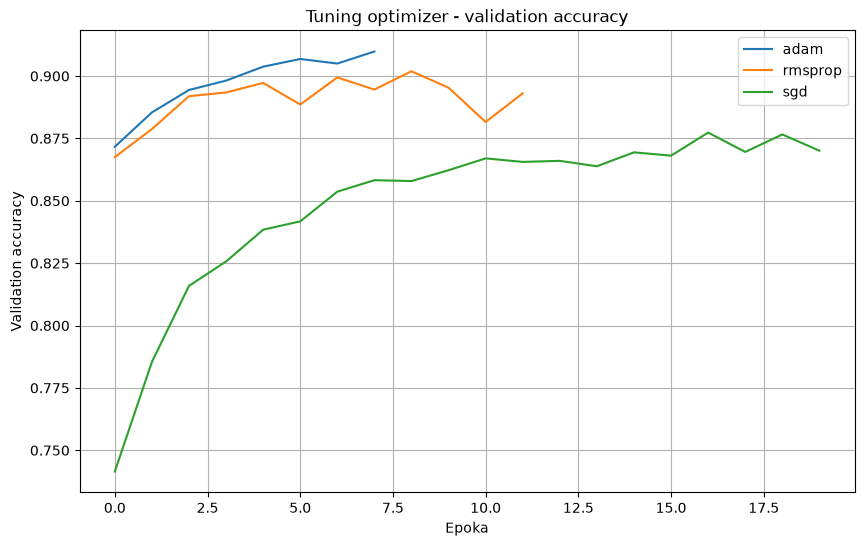

In [39]:
plt.figure(figsize=(10, 6))

for optimizer_name, history in optimizer_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=optimizer_name
    )

plt.title("Tuning optimizer - validation accuracy")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

# WNIOSKI - TUNING OPTIMIZER

Model z optymalizatorem Adam osiągnął najlepsze wyniki spośród wszystkich testowanych metod. Najwyższa validation accuracy wyniosła około 91,0%, a najniższa validation loss 0,2675. Model uczył się szybko i stabilnie, osiągając wysoką skuteczność już po kilku epokach. Pierwsze oznaki przeuczenia pojawiły się po około 5–6 epoce, jednak nie wpłynęły znacząco na końcową jakość klasyfikacji.

Model wykorzystujący RMSprop również osiągnął wysoką dokładność, jednak wyniki były nieco gorsze niż w przypadku Adama. Validation accuracy osiągnęła maksymalnie około 90,2%, a przebieg uczenia był mniej stabilny. W kolejnych epokach obserwowano większe wahania zarówno dokładności, jak i wartości funkcji straty, co wskazuje na mniej stabilny proces optymalizacji.

Model z optymalizatorem SGD uczył się zdecydowanie najwolniej. Pomimo systematycznej poprawy wyników przez cały trening, najwyższa validation accuracy wyniosła jedynie około 87,7%. Jednocześnie model nie wykazywał wyraźnych oznak przeuczenia,

# CNN + AUGMENTATION

In [40]:
# Augmentacja danych polega na tworzeniu nowych, losowo zmodyfikowanych
# wersji istniejących obrazów podczas treningu.
#
# Dzięki temu model widzi bardziej zróżnicowane przykłady,
# mimo że liczba oryginalnych obrazów w zbiorze nie zmienia się.
#
# W tym przypadku stosujemy:
# - niewielkie przesunięcie obrazu,
# - niewielki obrót,
# - niewielkie przybliżenie.
#
# Takie modyfikacje pomagają ograniczyć przeuczenie modelu
# i poprawiają jego zdolność generalizacji.
#
# Nie stosujemy agresywnej augmentacji, ponieważ obrazy Fashion-MNIST
# są niewielkie (28×28 pikseli) i zbyt duże modyfikacje mogłyby
# zniekształcić obiekty znajdujące się na obrazach.

data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(0.08, 0.08), #losowe przesunięcie o 8% wysokości i szerokości
    keras.layers.RandomRotation(0.08), #losowy obrót o 8%
    keras.layers.RandomZoom(0.1) #losowe przybliżenie/oddalenie o 10%
])

In [41]:
# Model CNN z augmentacją danych.
# Augmentacja działa tylko podczas treningu.
# Podczas walidacji i testowania obrazy nie są losowo zmieniane. 
# Celem jest sztuczne zwiększenie różnorodności danych treningowych, a nie utrudnianie oceny modelu.

cnn_augmentation = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(10, activation="softmax")
])

cnn_augmentation.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_15 (Sequential)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Trenowanie modelu: CNN + Augmentation
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6936 - loss: 0.8104 - val_accuracy: 0.7534 - val_loss: 0.6654
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7678 - loss: 0.6080 - val_accuracy: 0.8200 - val_loss: 0.4919
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7948 - loss: 0.5469 - val_accuracy: 0.8277 - val_loss: 0.4648
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8107 - loss: 0.5070 - val_accuracy: 0.8322 - val_loss: 0.4626
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8186 - loss: 0.4798 - val_accuracy: 0.8374 - val_loss: 0.4446
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8271 - loss: 0.4588 - val_accuracy: 0.8422 - val_loss: 0.4304
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8328 - loss: 0.4464 - val_accuracy: 0.8537 - val_loss: 0.3991
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/ste

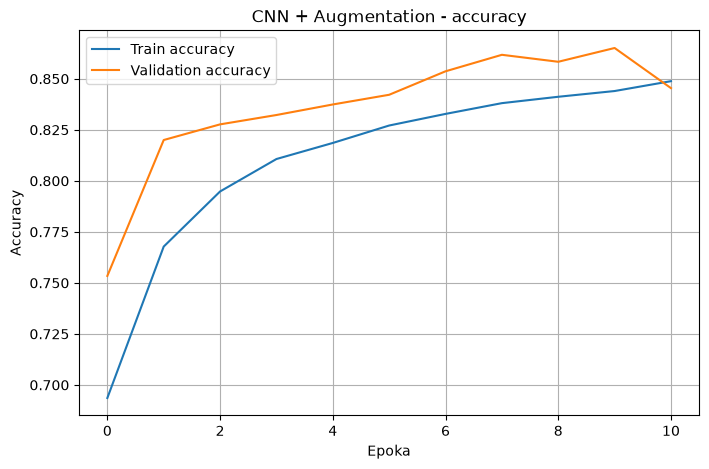

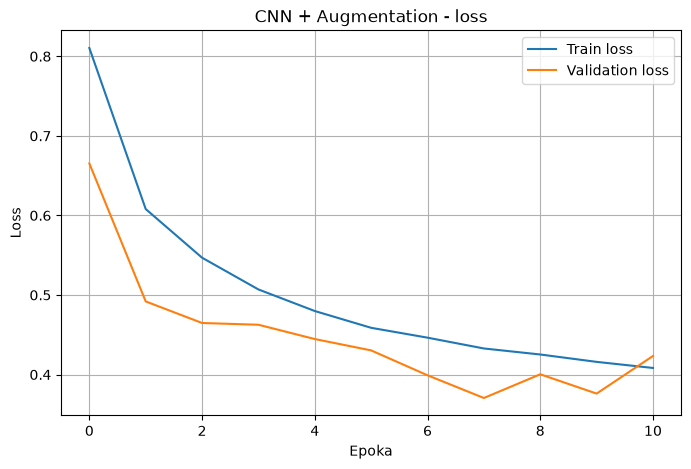

In [42]:
#Trenowanie
history_cnn_augmentation = compile_and_train(
    model=cnn_augmentation,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + Augmentation",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + Augmentation", history_cnn_augmentation)
plot_learning_curves(history_cnn_augmentation, "CNN + Augmentation")

# WNIOSKI CNN + AUGMENTATION

Model CNN + Augmentation osiągnął najlepszą dokładność walidacyjną na poziomie około 86,5% oraz validation loss = 0,3705. Wynik ten był wyraźnie niższy niż w przypadku podstawowego modelu CNN oraz jego wersji z Dropout.

Zastosowanie augmentacji danych spowodowało, że model od początku uczył się na bardziej zróżnicowanych i trudniejszych przykładach. W efekcie accuracy na zbiorze treningowym rosło wolniej niż w poprzednich eksperymentach, jednak model był mniej podatny na szybkie przeuczenie.

W pierwszych dziesięciu epokach obserwowano stopniowy wzrost dokładności oraz spadek wartości funkcji straty na zbiorze walidacyjnym. Najlepszy wynik walidacyjny został osiągnięty w 10. epoce, co oznacza, że model potrzebował więcej czasu na nauczenie się danych niż modele bez augmentacji.

Po 10. epoce pojawiły się pierwsze oznaki pogorszenia jakości uogólniania. Validation accuracy spadło z 86,5% do 84,5%, a validation loss wzrosło z 0,3761 do 0,4234, mimo dalszej poprawy wyników na zbiorze treningowym. Świadczy to o rozpoczęciu procesu przeuczenia.

W porównaniu z pozostałymi eksperymentami augmentacja nie poprawiła skuteczności klasyfikacji. Prawdopodobną przyczyną jest charakter zbioru Fashion-MNIST – obrazy mają niewielki rozmiar (28×28 pikseli) i przedstawiają odzież w ustalonej orientacji. Nawet niewielkie losowe przesunięcia, obroty czy przybliżenia mogły utrudniać rozpoznawanie charakterystycznych cech obrazów.

# CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION

In [43]:
# BatchNormalization normalizuje aktywacje wewnątrz sieci. Dla każdego batcha oblicza: średnią i odchylenie standardowe i przekształca aktywacje tak, 
# aby miały w przybliżeniu: średnia = 0, odchylenie = 1.
# Sabilizuje to trening i przyspiesza uczenie.
# Często stosuje się ją w kolejnych warstwach.

cnn_batchnorm = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),

    keras.layers.Conv2D(32, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(), # po conv2D aby normalizować powstające mapy cech
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.3), #mały zbiór, tutaj batch normalization nie dałoby już znaczącej poprawy

    keras.layers.Dense(10, activation="softmax")
])

cnn_batchnorm.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

Trenowanie modelu: CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8264 - loss: 0.4847 - val_accuracy: 0.8865 - val_loss: 0.3120
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8758 - loss: 0.3376 - val_accuracy: 0.8810 - val_loss: 0.3268
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8952 - loss: 0.2857 - val_accuracy: 0.8995 - val_loss: 0.2795
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9047 - loss: 0.2556 - val_accuracy: 0.9053 - val_loss: 0.2639
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9128 - loss: 0.2308 - val_accuracy: 0.9035 - val_loss: 0.2859
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9195 - loss: 0.2137 - val_accuracy: 0.8987 - val_loss: 0.3125
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9269 - loss: 0.1916 - val_accuracy: 0.8771 - val_loss: 0.4087


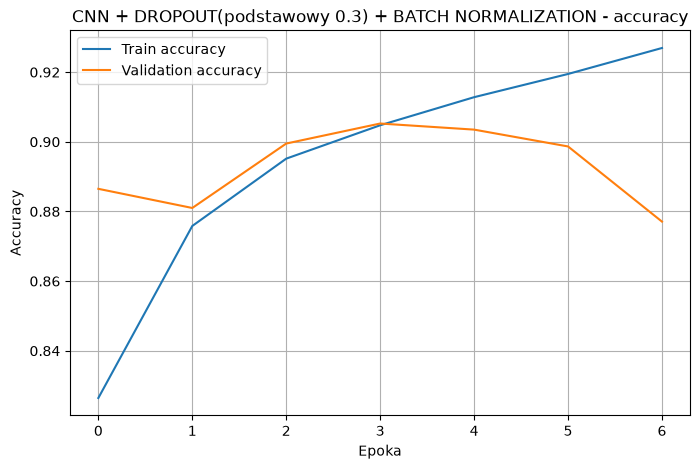

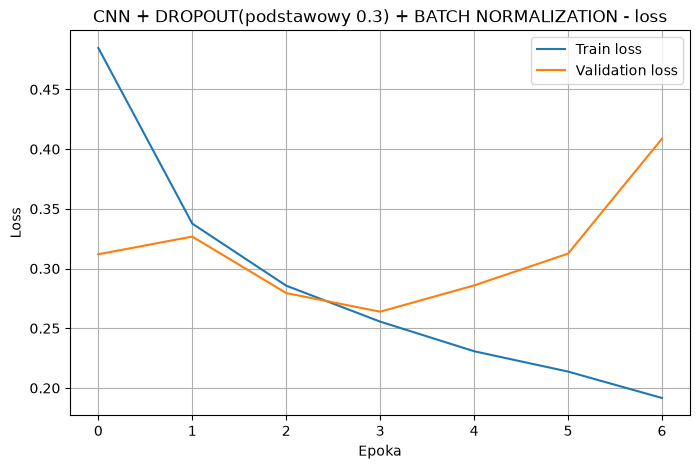

In [44]:
#Trening
history_cnn_batchnorm = compile_and_train(
    model=cnn_batchnorm,
    X_train_data=X_train_cnn,
    y_train_data=y_train_part,
    X_val_data=X_val_cnn,
    y_val_data=y_val,
    model_name="CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION",
    epochs=20,
    batch_size=32,
    learning_rate=0.001,
    optimizer_name="adam"
)

save_result("CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION", history_cnn_batchnorm)
plot_learning_curves(history_cnn_batchnorm, "CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION")

# WNIOSKI CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION

Model CNN z warstwami Dropout i BatchNormalization osiągnął najlepszą dokładność walidacyjną na poziomie około 90,5% oraz validation loss = 0,2639. Wyniki były bardzo zbliżone do podstawowego modelu CNN z Dropout.

W pierwszych czterech epokach obserwowano systematyczny wzrost dokładności oraz spadek wartości funkcji straty zarówno na zbiorze treningowym, jak i walidacyjnym. Najlepszy wynik walidacyjny został osiągnięty w 4. epoce, po czym jakość klasyfikacji zaczęła się pogarszać.

Od 5. epoki accuracy na zbiorze treningowym nadal rosło (do około 92,7%), natomiast validation accuracy stopniowo malało, a validation loss wyraźnie wzrastało. Jest to typowy sygnał rozpoczęcia przeuczenia modelu.

W porównaniu z modelem CNN + Dropout, dodanie BatchNormalization nie przyniosło poprawy skuteczności klasyfikacji. Model osiągnął nieco niższą dokładność walidacyjną (90,5% vs 91,0%), a proces uczenia zakończył się wcześniej z powodu pogorszenia wyników walidacyjnych.

# ZBIORCZY TUNING KOMBINACJI HIPERPARAMETRÓW

In [45]:
def build_cnn_combo_model(dropout_rate=0.5, use_augmentation=False):
    """
    Funkcja tworzy model CNN używany w końcowym tuningu kombinacji hiperparametrów.

    Parametry:
    - dropout_rate: wartość Dropout,
    - use_augmentation: czy model ma zawierać augmentację danych.

    Dzięki tej funkcji możemy łatwo tworzyć kilka modeli
    o tej samej architekturze, ale z różnymi ustawieniami.
    """

    layers = [
        keras.layers.Input(shape=(28, 28, 1))
    ]

    # Augmentacja danych jest dodawana tylko wtedy,
    # gdy use_augmentation=True.
    #
    # Augmentacja działa podczas treningu i tworzy lekko zmienione wersje obrazów.
    # Pomaga to ograniczyć przeuczenie modelu.
    if use_augmentation:
        layers.append(
            keras.Sequential([
                keras.layers.RandomTranslation(0.08, 0.08),
                keras.layers.RandomRotation(0.08),
                keras.layers.RandomZoom(0.1)
            ])
        )

    layers.append(
        keras.layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        )
    )

    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    layers.append(
        keras.layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        )
    )

    layers.append(
        keras.layers.MaxPooling2D((2, 2))
    )

    layers.append(
        keras.layers.Flatten()
    )

    layers.append(
        keras.layers.Dense(
            128,
            activation="relu"
        )
    )

    layers.append(
        keras.layers.Dropout(dropout_rate)
    )

    layers.append(
        keras.layers.Dense(
            10,
            activation="softmax"
        )
    )

    model = keras.Sequential(layers)

    return model

## Lista końcowych kombinacji

In [46]:
# Na podstawie wcześniejszych eksperymentów wybrano najbardziej obiecujące wartości:
#
# - Dropout: 0.5 dał najlepszy wynik w osobnym teście.
# - Learning rate: 0.001 i 0.0005 osiągnęły najlepsze wyniki.
# - Optimizer: Adam był najlepszy, ale RMSprop również zostaje sprawdzony kontrolnie.
# - Augmentation: sprawdzamy warianty z augmentacją i bez augmentacji.
#
# Nie testujemy SGD, learning rate 0.01 ani 0.0001,
# ponieważ we wcześniejszych wynikach były wyraźnie słabsze.

combo_settings = [

    # 1. Najlepszy dropout + najlepszy learning rate + Adam, bez augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": False},

    # 2. To samo, ale z augmentacją
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 3. Adam z mniejszym learning rate, bez augmentacji
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": False},

    # 4. Adam z mniejszym learning rate i augmentacją
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "adam", "augmentation": True},

    # 5. Sprawdzenie, czy mniejszy Dropout 0.3 lepiej współpracuje z augmentacją
    {"dropout": 0.3, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 6. Sprawdzenie jeszcze słabszej regularyzacji Dropout 0.2 z augmentacją
    {"dropout": 0.2, "lr": 0.001,  "optimizer": "adam", "augmentation": True},

    # 7. RMSprop jako alternatywa dla Adama przy najlepszym Dropout i augmentacji
    {"dropout": 0.5, "lr": 0.001,  "optimizer": "rmsprop", "augmentation": True},

    # 8. RMSprop z mniejszym learning rate
    {"dropout": 0.5, "lr": 0.0005, "optimizer": "rmsprop", "augmentation": True}
]

## Trenowanie modeli z kombinacjami

In [47]:
# Słowniki do zapisania historii treningu i modeli.
# Dzięki temu po treningu będzie można porównać wyniki
# oraz wybrać najlepszy model.

combo_histories = {}
combo_models = {}
combo_results = []

In [48]:
for i, params in enumerate(combo_settings, start=1):

    # Pobieramy wartości hiperparametrów z aktualnej konfiguracji.
    dropout_rate = params["dropout"]
    lr = params["lr"]
    optimizer_name = params["optimizer"]
    use_augmentation = params["augmentation"]

    # Tworzymy czytelną nazwę modelu.
    model_name = (
        f"Combo {i}: "
        f"dropout={dropout_rate}, "
        f"lr={lr}, "
        f"opt={optimizer_name}, "
        f"aug={use_augmentation}"
    )

    print("=" * 90)
    print(model_name)
    print("=" * 90)

    # Dla każdej kombinacji tworzymy nowy model od zera.
    # ponieważ każdy eksperyment powinien startować
    # od nowej inicjalizacji wag.
    model = build_cnn_combo_model(
        dropout_rate=dropout_rate,
        use_augmentation=use_augmentation
    )

    # Trenujemy model dla aktualnej kombinacji hiperparametrów.
    history = compile_and_train(
        model=model,
        X_train_data=X_train_cnn,
        y_train_data=y_train_part,
        X_val_data=X_val_cnn,
        y_val_data=y_val,
        model_name=model_name,
        epochs=20,
        batch_size=32,
        learning_rate=lr,
        optimizer_name=optimizer_name
    )

    # Zapisujemy historię treningu i model.
    combo_histories[model_name] = history
    combo_models[model_name] = model

    # Zbieramy najważniejsze wyniki do osobnej tabeli.
    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])
    epochs_trained = len(history.history["loss"])

    combo_results.append({
        "Model": model_name,
        "Dropout": dropout_rate,
        "Learning rate": lr,
        "Optimizer": optimizer_name,
        "Augmentation": use_augmentation,
        "Best val_accuracy": best_val_accuracy,
        "Best val_loss": best_val_loss,
        "Liczba epok": epochs_trained
    })

    # Zapisujemy wynik również do głównej listy results
    save_result(model_name, history)

Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Trenowanie modelu: Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7940 - loss: 0.5738 - val_accuracy: 0.8623 - val_loss: 0.3691
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8618 - loss: 0.3845 - val_accuracy: 0.8789 - val_loss: 0.3274
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8797 - loss: 0.3320 - val_accuracy: 0.8948 - val_loss: 0.2833
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8911 - loss: 0.3015 - val_accuracy: 0.8981 - val_loss: 0.2766
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8992 - loss: 0.2758 - val_accuracy: 0.9048 - val_loss: 0.2664
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9062 - loss: 0.2572 - val_accuracy: 0.9036 - val_loss: 0.2635
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9113 - loss: 0.2400 - val_acc

## Tabela wyników dla kombinacji

In [49]:
# Tworzymy tabelę z wynikami wszystkich kombinacji.

combo_results_df = pd.DataFrame(combo_results)

# Sortujemy od najlepszego wyniku validation accuracy.

combo_results_df = combo_results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

pd.set_option("display.max_colwidth", None)
combo_results_df

,Model,Dropout,Learning rate,Optimizer,Augmentation,Best val_accuracy,Best val_loss,Liczba epok
2,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.5,0.0005,adam,False,0.914833,0.247945,15
0,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False",0.5,0.0010,adam,False,0.912833,0.253287,12
5,"Combo 6: dropout=0.2, lr=0.001, opt=adam, aug=True",0.2,0.0010,adam,True,0.874667,0.351027,19
1,"Combo 2: dropout=0.5, lr=0.001, opt=adam, aug=True",0.5,0.0010,adam,True,0.873917,0.360424,20
4,"Combo 5: dropout=0.3, lr=0.001, opt=adam, aug=True",0.3,0.0010,adam,True,0.872417,0.348175,13
3,"Combo 4: dropout=0.5, lr=0.0005, opt=adam, aug=True",0.5,0.0005,adam,True,0.869250,0.355138,20
7,"Combo 8: dropout=0.5, lr=0.0005, opt=rmsprop, aug=True",0.5,0.0005,rmsprop,True,0.846250,0.450816,13
6,"Combo 7: dropout=0.5, lr=0.001, opt=rmsprop, aug=True",0.5,0.0010,rmsprop,True,0.831167,0.462374,10


## Wykres porównania kombinacji

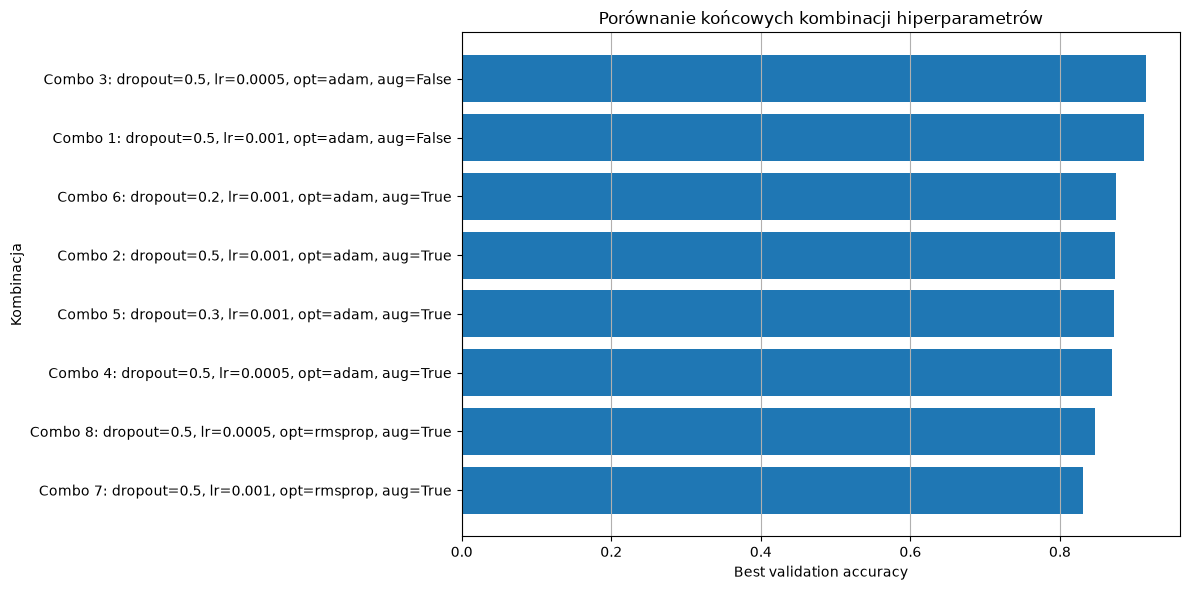

In [50]:
plt.figure(figsize=(12, 6))

plt.barh(
    combo_results_df["Model"],
    combo_results_df["Best val_accuracy"]
)

plt.title("Porównanie końcowych kombinacji hiperparametrów")
plt.xlabel("Best validation accuracy")
plt.ylabel("Kombinacja")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

## Krzywe uczenia dla kombinacji

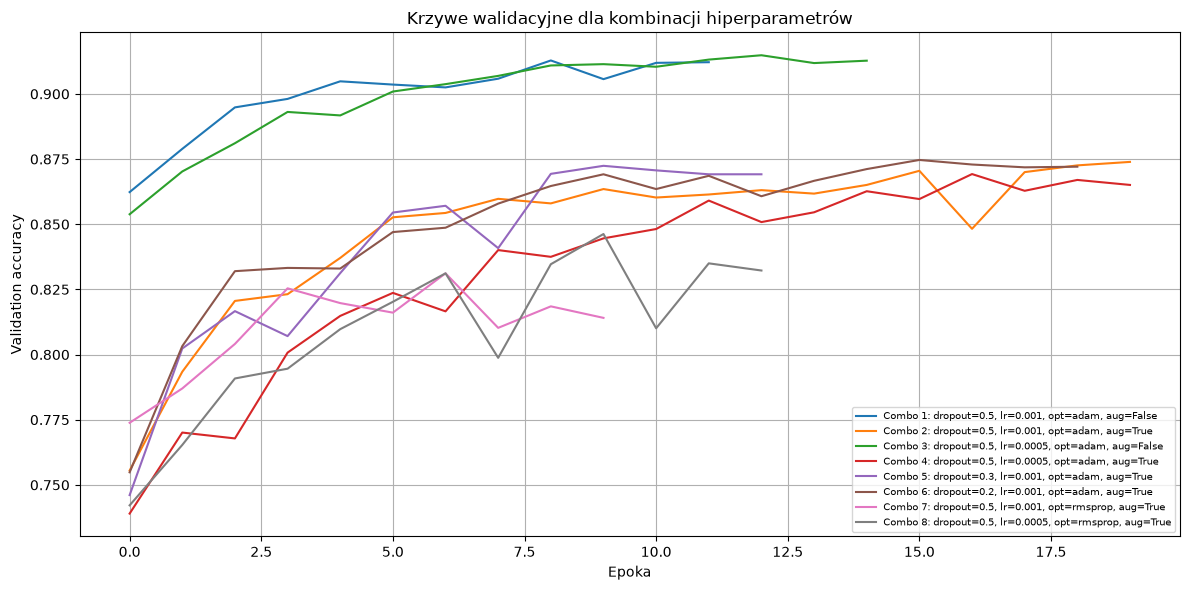

In [51]:
plt.figure(figsize=(12, 6))

for model_name, history in combo_histories.items():
    plt.plot(
        history.history["val_accuracy"],
        label=model_name
    )

plt.title("Krzywe walidacyjne dla kombinacji hiperparametrów")
plt.xlabel("Epoka")
plt.ylabel("Validation accuracy")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

# WNIOSKI - KOMBINACJE

Combo 1 (dropout=0.5, lr=0.001, Adam, bez augmentacji)
    Model osiągnął 91,28% validation accuracy oraz 0,2533 validation loss (9. epoka).
    Uczenie przebiegało stabilnie, a model należał do najlepszych spośród wszystkich testowanych konfiguracji.
    Po około 9. epoce pojawiły się pierwsze oznaki przeuczenia.

Combo 2 (dropout=0.5, lr=0.001, Adam, z augmentacją)
    Maksymalna skuteczność wyniosła jedynie około 87,4%.
    Model uczył się znacznie wolniej niż jego odpowiednik bez augmentacji.
    Augmentacja wyraźnie obniżyła skuteczność klasyfikacji.

Combo 3 (dropout=0.5, lr=0.0005, Adam, bez augmentacji)
    Osiągnął najlepszy wynik spośród wszystkich modeli – około 91,48% validation accuracy przy validation loss ≈ 0,248 (12–13. epoka).
    Mniejszy learning rate zapewnił bardziej stabilne uczenie i lepszą generalizację.
    Model stanowi najlepszy kompromis pomiędzy szybkością uczenia a końcową jakością klasyfikacji.

Combo 4 (dropout=0.5, lr=0.0005, Adam, z augmentacją)
    Maksymalna dokładność wyniosła około 86,9%.
    Mimo zmniejszenia learning rate wyniki nadal były znacznie słabsze niż bez augmentacji.
    Potwierdza to, że sama zmiana learning rate nie rekompensuje negatywnego wpływu augmentacji.

Combo 5 (dropout=0.3, lr=0.001, Adam, z augmentacją)
    Najlepszy wynik to około 87,2% validation accuracy.
    Zmniejszenie Dropoutu z 0.5 do 0.3 nie poprawiło wyników w obecności augmentacji.
    Model nadal pozostawał wyraźnie słabszy od konfiguracji bez augmentacji.

Combo 6 (dropout=0.2, lr=0.001, Adam, z augmentacją)
    Osiągnął około 87,5% validation accuracy.
    Był nieznacznie lepszy od Combo 5, jednak nadal wyraźnie ustępował modelom bez augmentacji.
    Zmniejszenie Dropoutu poprawiło uczenie jedynie w niewielkim stopniu.

Combo 7 (dropout=0.5, lr=0.001, RMSprop, z augmentacją)
    Maksymalna dokładność wyniosła około 83,1%.
    Model wykazywał dużą niestabilność, a validation loss silnie się wahał.
    Połączenie RMSprop z augmentacją okazało się nieefektywne.

Combo 8 (dropout=0.5, lr=0.0005, RMSprop, z augmentacją)
    Uzyskano około 84,6% validation accuracy.
    Obniżenie learning rate nie poprawiło jakości klasyfikacji w stosunku do Combo 7.
    RMSprop ponownie osiągnął słabsze wyniki niż Adam.

Wniosek końcowy

Najlepszym modelem okazał się Combo 3 (Dropout = 0.5, learning rate = 0.0005, Adam, bez augmentacji), który osiągnął najwyższą skuteczność klasyfikacji oraz najniższą wartość validation loss. Eksperyment wykazał, że:

Adam był zdecydowanie skuteczniejszym optymalizatorem niż RMSprop,
learning rate = 0.0005 zapewnił lepszą stabilność uczenia niż 0.001,
Dropout = 0.5 skutecznie ograniczał przeuczenie,
augmentacja danych nie poprawiła wyników, a wręcz pogorszyła skuteczność modeli, co sugeruje, że dla prostego i dobrze wycentrowanego zbioru Fashion-MNIST nie była ona korzystnym rozwiązaniem.

## Wybór najlepszej kombinacji

In [52]:
# Pobieramy najlepszą kombinację z pierwszego wiersza posortowanej tabeli.

best_combo_name = combo_results_df.iloc[0]["Model"]
best_combo_model = combo_models[best_combo_name]

print("Najlepsza kombinacja hiperparametrów:")
print(best_combo_name)

print(
    f"Best validation accuracy: "
    f"{combo_results_df.iloc[0]['Best val_accuracy']:.4f}"
)

print(
    f"Best validation loss: "
    f"{combo_results_df.iloc[0]['Best val_loss']:.4f}"
)

Najlepsza kombinacja hiperparametrów:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Best validation accuracy: 0.9148
Best validation loss: 0.2479


# WNIOSKI - NAJLEPSZA KOMBINACJA

Najlepszą konfiguracją okazał się model Combo 3:
Dropout = 0.5,
Learning Rate = 0.0005,
Optimizer = Adam,
bez augmentacji danych.

Model ten osiągnął najwyższą dokładność walidacyjną i został wybrany do dalszej ewaluacji na zbiorze testowym.
Na podstawie wyników można przypuszczać, że dodanie BatchNormalization do najlepszej konfiguracji Combo 3 mogłoby potencjalnie poprawić stabilność treningu i nieznacznie zwiększyć accuracy. Jednak ponieważ model Combo 3 już osiągnął najwyższy wynik walidacyjny, a różnica względem modelu z BatchNormalization była niewielka, w tym przypadku zysk również byłby nieznaczny lub żaden.

# ZBIORCZE WYNIKI DLA WSZYSTKICH MODELI

In [53]:
# Tworzymy DataFrame ze wszystkich wyników.

results_df = pd.DataFrame(results)

# Sortujemy modele od najlepszego do najgorszego.
results_df = results_df.sort_values(
    by="Best val_accuracy",
    ascending=False
)

# Resetujemy indeks.
results_df = results_df.reset_index(drop=True)

# Dodajemy ranking.
results_df.insert(
    0,
    "Ranking",
    range(1, len(results_df) + 1)
)

pd.set_option("display.max_colwidth", None)
results_df

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.914833,0.247945,15
1,2,CNN Dropout 0.3,0.914167,0.260162,10
2,3,CNN LR 0.0005,0.913083,0.253627,13
3,4,"Combo 1: dropout=0.5, lr=0.001, opt=adam, aug=False",0.912833,0.253287,12
4,5,CNN Dropout 0.5,0.912167,0.252856,9
5,6,CNN + Dropout,0.909917,0.261476,8
6,7,CNN LR 0.001,0.909833,0.255286,9
7,8,CNN optimizer adam,0.909833,0.267456,8
8,9,CNN Dropout 0.2,0.909000,0.264873,8
9,10,CNN LR 0.0001,0.906917,0.260762,20


# Podsumowanie eksperymentów

Spośród 25 przetestowanych modeli najlepsze wyniki osiągnął Combo 3 (Dropout = 0.5, learning rate = 0.0005, Adam, bez augmentacji), uzyskując 91,48% validation accuracy oraz najniższą wartość validation loss (0,2479). Oznacza to, że odpowiednio dobrane hiperparametry pozwoliły osiągnąć najwyższą skuteczność klasyfikacji.

W czołówce rankingu znalazły się wyłącznie modele CNN bez augmentacji danych. Różnice pomiędzy pierwszymi pięcioma miejscami były niewielkie (poniżej 0,3 p.p.), co świadczy o tym, że architektura CNN była już dobrze dopasowana do problemu, a tuning hiperparametrów dawał jedynie stopniowe usprawnienia.

Największy wpływ na poprawę wyników miał tuning Dropoutu oraz learning rate. Szczególnie dobrze sprawdziły się wartości Dropout = 0.3–0.5 oraz learning rate = 0.0005, które zapewniały dobrą równowagę między szybkością uczenia a zdolnością modelu do generalizacji.

Dodanie Batch Normalization nie poprawiło wyników względem najlepiej dostrojonych modeli CNN. Model z Batch Normalization osiągnął 90,53% validation accuracy, czyli wynik zbliżony do podstawowego CNN, lecz niższy od najlepszych konfiguracji z odpowiednio dobranym Dropoutem.

Optymalizator Adam okazał się zdecydowanie najlepszym wyborem. Zarówno RMSprop, jak i SGD uzyskały niższą dokładność oraz wyższe wartości validation loss, co potwierdza lepszą skuteczność Adama dla analizowanego problemu.

Modele MLP (zarówno pojedyncza, jak i głębsza sieć) osiągnęły około 88,6% validation accuracy, co było wyraźnie słabszym wynikiem od modeli CNN. Pokazuje to przewagę sieci konwolucyjnych w zadaniach klasyfikacji obrazów.

Augmentacja danych nie przyniosła oczekiwanej poprawy. Wszystkie modele wykorzystujące augmentację zajęły dolną część rankingu, osiągając wyniki na poziomie około 86–87%, czyli o około 4–5 punktów procentowych niższe od najlepszych modeli. Dla zbioru Fashion-MNIST dodatkowe transformacje obrazów okazały się niekorzystne.

Najsłabszym modelem był Combo 7 (Dropout = 0.5, learning rate = 0.001, RMSprop, augmentacja), który uzyskał 83,12% validation accuracy oraz najwyższą wartość validation loss spośród wszystkich testowanych konfiguracji.

WNIOSEK KOŃCOWY

Przeprowadzone eksperymenty pokazują, że największy wpływ na jakość klasyfikacji miała architektura CNN oraz odpowiedni dobór hiperparametrów, przede wszystkim wartości Dropoutu, learning rate oraz optymalizatora Adam. Najlepsze rezultaty osiągnięto bez stosowania augmentacji danych, co wskazuje, że dla zbioru Fashion-MNIST prostszy proces uczenia pozwala uzyskać lepszą generalizację niż dodatkowe przekształcenia obrazów.

# WYBÓR NAJLEPSZEGO MODELU

In [54]:
# Na podstawie validation accuracy wybieramy model,
# który osiągnął najwyższą skuteczność na zbiorze walidacyjnym.
best_model_name = results_df.iloc[0]["Model"]

print("Najlepszy model:")
print(best_model_name)

Najlepszy model:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False


# 3 pierwsze modele zostały wybrane do dalszej ewaluacji na zbiorze testowym.

# EWALUACJA NA ZBIORZE TESTOWYM

In [55]:
# Tworzymy słownik wszystkich wytrenowanych modeli.

all_models = {
    "Baseline": baseline_model,
    "MLP 128": mlp_128,
    "MLP Deep": mlp_deep,
    "CNN": cnn_model,
    "CNN + Dropout": cnn_dropout,
    "CNN + Augmentation": cnn_augmentation,
    "CNN + DROPOUT(podstawowy 0.3) + BATCH NORMALIZATION": cnn_batchnorm
}

# Modele z tuningu Dropout.
for dropout_rate, model in dropout_models.items():
    all_models[f"CNN Dropout {dropout_rate}"] = model

# Modele z tuningu learning rate.
for lr, model in lr_models.items():
    all_models[f"CNN LR {lr}"] = model

# Modele z tuningu optymalizatora.
for optimizer_name, model in optimizer_models.items():
    all_models[f"CNN optimizer {optimizer_name}"] = model

# Modele z końcowych kombinacji hiperparametrów.
for model_name, model in combo_models.items():
    all_models[model_name] = model

In [56]:
# Pobieramy 3 najlepsze modele według validation accuracy.

top3 = results_df.head(3)

pd.set_option("display.max_colwidth", None)
top3

,Ranking,Model,Best val_accuracy,Best val_loss,Liczba epok
0,1,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.914833,0.247945,15
1,2,CNN Dropout 0.3,0.914167,0.260162,10
2,3,CNN LR 0.0005,0.913083,0.253627,13


In [57]:
# Lista do przechowywania wyników testowych.

test_results = []

# Przechodzimy po trzech najlepszych modelach.
for _, row in top3.iterrows():

    model_name = row["Model"]

    print(f"Testowanie modelu: {model_name}")

    # Pobieramy model ze słownika.
    model = all_models[model_name]

    # Obliczamy wynik na zbiorze testowym.
    test_loss, test_accuracy = model.evaluate(
        X_test_cnn,
        y_test,
        verbose=0
    )

    # Zapisujemy wyniki.
    test_results.append({
        "Model": model_name,
        "Validation accuracy": row["Best val_accuracy"],
        "Test accuracy": test_accuracy,
        "Test loss": test_loss
    })

Testowanie modelu: Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False
Testowanie modelu: CNN Dropout 0.3
Testowanie modelu: CNN LR 0.0005


# TABELA WYNIKÓW EWALUACJI NA ZBIORZE TESTOWYM

In [58]:
test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    by="Test accuracy",
    ascending=False
)

pd.set_option("display.max_colwidth", None)
test_results_df

,Model,Validation accuracy,Test accuracy,Test loss
0,"Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False",0.914833,0.9035,0.272068
1,CNN Dropout 0.3,0.914167,0.9030,0.275425
2,CNN LR 0.0005,0.913083,0.9023,0.270995


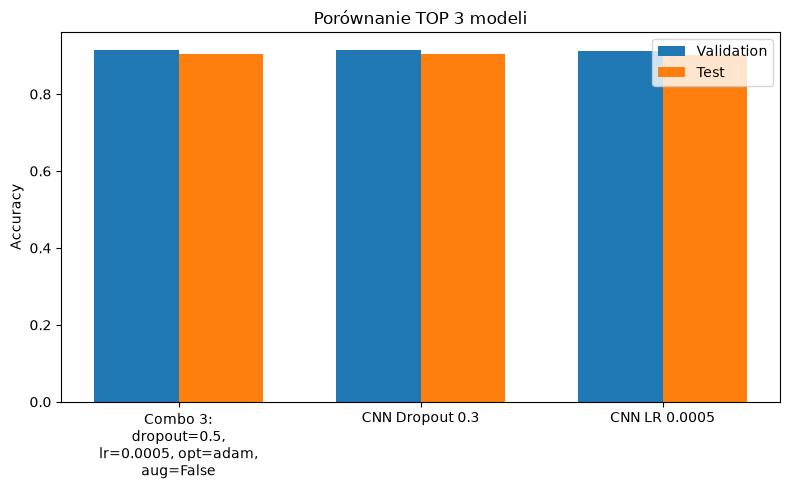

In [59]:
import textwrap
plt.figure(figsize=(8, 5))

x = np.arange(len(test_results_df))

width = 0.35

plt.bar(
    x - width/2,
    test_results_df["Validation accuracy"],
    width,
    label="Validation"
)

plt.bar(
    x + width/2,
    test_results_df["Test accuracy"],
    width,
    label="Test"
)

#zawijanie tekstu podpisów
wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in test_results_df["Model"]
]

plt.xticks(
    x,
    wrapped_labels
)

plt.ylabel("Accuracy")
plt.title("Porównanie TOP 3 modeli")

plt.legend()

plt.tight_layout()
plt.show()

# WNIOSKI - EWALUACJA NA ZBIORZE TESTOWYM

Wszystkie trzy najlepsze modele uzyskały bardzo zbliżoną skuteczność na zbiorze testowym, przekraczając 90% accuracy, co potwierdza ich dobrą zdolność do generalizacji na nowych danych.

Najwyższą dokładność testową (90,35%) osiągnął Combo 3 (Dropout = 0.5, learning rate = 0.0005, Adam, bez augmentacji). Model ten był również najlepszy podczas walidacji, co świadczy o stabilnym procesie uczenia i dobrej odporności na przeuczenie.

CNN z Dropout = 0.3, mimo niemal identycznej skuteczności na zbiorze walidacyjnym (91,42%), uzyskał nieco niższą dokładność testową (90,30%) oraz najwyższą wartość test loss (0,2754) spośród trzech porównywanych modeli.

Model CNN z learning rate = 0.0005 osiągnął 90,23% accuracy, czyli minimalnie niższą od dwóch pozostałych modeli, jednak uzyskał najniższą wartość test loss (0,2710). Oznacza to, że jego predykcje były średnio najbardziej pewne i najlepiej dopasowane do rzeczywistych klas.

Różnice pomiędzy modelami są bardzo niewielkie (około 0,1–0,3 punktu procentowego), dlatego wszystkie trzy konfiguracje można uznać za porównywalnie skuteczne.

WNIOSEK KOŃCOWY

Najlepszym modelem pozostaje Combo 3, który osiągnął najwyższą dokładność zarówno na zbiorze walidacyjnym, jak i testowym. Jednocześnie wyniki pokazują, że odpowiedni dobór hiperparametrów (Dropout oraz learning rate) miał większy wpływ na końcową skuteczność niż dalsze modyfikowanie architektury sieci. Wszystkie trzy najlepsze modele charakteryzują się dobrą zdolnością generalizacji, co potwierdza ich wysoką jakość na danych testowych.

# DALSZA ANALIZA NAJLEPSZEGO MODELU

In [60]:
# Wybieramy model, który uzyskał najwyższe accuracy na zbiorze testowym.

final_model_name = test_results_df.iloc[0]["Model"]

final_model = all_models[final_model_name]

print("Finalny model:")
print(final_model_name)

Finalny model:
Combo 3: dropout=0.5, lr=0.0005, opt=adam, aug=False


## Predykcje finalnego modelu

In [61]:
# Model zwraca prawdopodobieństwa dla każdej z 10 klas.
# Za ostateczną predykcję przyjmujemy klasę z najwyższym prawdopodobieństwem.

y_pred_probs = final_model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


## Raport klasyfikacji

In [62]:

# Raport klasyfikacji pokazuje wyniki osobno dla każdej klasy:
#
# Precision (precyzja)
# Spośród wszystkich przykładów przypisanych przez model do danej klasy,
# jaki procent rzeczywiście należał do tej klasy.
#
# Recall (czułość)
# Spośród wszystkich rzeczywistych przykładów danej klasy,
# jaki procent został poprawnie wykryty przez model.
#
# F1-score
# Średnia harmoniczna precision i recall.
# Jest dobrą miarą ogólnej jakości klasyfikacji dla danej klasy.
#
# Support
# Liczba przykładów danej klasy występujących w zbiorze testowym.

from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Klasy
print("WYNIKI DLA POSZCZEGÓLNYCH KLAS\n")
display(report_df.iloc[:10])

print("\nWYNIKI DLA CAŁEGO MODELU\n")

# accuracy + avg
display(report_df.iloc[10:])

WYNIKI DLA POSZCZEGÓLNYCH KLAS



,precision,recall,f1-score,support
T-shirt/top,0.854271,0.850,0.852130,1000.0
Trouser,0.997947,0.972,0.984802,1000.0
Pullover,0.852736,0.857,0.854863,1000.0
Dress,0.893451,0.914,0.903609,1000.0
Coat,0.869703,0.821,0.844650,1000.0
Sandal,0.978131,0.984,0.981057,1000.0
Shirt,0.694340,0.736,0.714563,1000.0
Sneaker,0.948141,0.969,0.958457,1000.0
Bag,0.980924,0.977,0.978958,1000.0
Ankle boot,0.979487,0.955,0.967089,1000.0



WYNIKI DLA CAŁEGO MODELU



,precision,recall,f1-score,support
accuracy,0.903500,0.9035,0.903500,0.9035
macro avg,0.904913,0.9035,0.904018,10000.0000
weighted avg,0.904913,0.9035,0.904018,10000.0000


# WNIOSKI - KLASYFIKACJA

Najlepiej rozpoznawanymi klasami były Trouser, Sandal, Bag, Sneaker oraz Ankle boot, dla których wartości precision, recall oraz F1-score przekroczyły 0,95. Oznacza to, że model bardzo rzadko mylił te elementy garderoby z innymi klasami.

Najwyższy wynik F1-score uzyskała klasa Trouser (0,9848), co świadczy o bardzo wysokiej skuteczności zarówno pod względem wykrywania tej klasy (recall = 0,972), jak i poprawności jej predykcji (precision = 0,998).

Dobre wyniki osiągnęły również klasy Dress (F1 = 0,9036), Pullover (0,8549) oraz T-shirt/top (0,8521). Choć skuteczność jest niższa niż dla obuwia i spodni, model nadal poprawnie rozpoznaje większość przykładów tych kategorii.

Największe trudności model miał z klasą Shirt, która uzyskała najniższy F1-score (0,7146), precision (0,6943) oraz stosunkowo niski recall (0,736). Oznacza to, że koszule były często mylone z innymi, wizualnie podobnymi elementami odzieży.

Relatywnie słabszy wynik osiągnęła również klasa Coat (F1 = 0,8447). Niższy recall (0,821) wskazuje, że część płaszczy została błędnie przypisana do innych kategorii.

Wysokie wartości macro average i weighted average (około 0,91, wyliczone dla całego raportu klasyfikacji) wskazują, że model utrzymuje wyrównaną skuteczność dla większości klas, a słabsze wyniki dotyczą jedynie kilku wizualnie podobnych kategorii odzieży.

## Macierz pomyłek

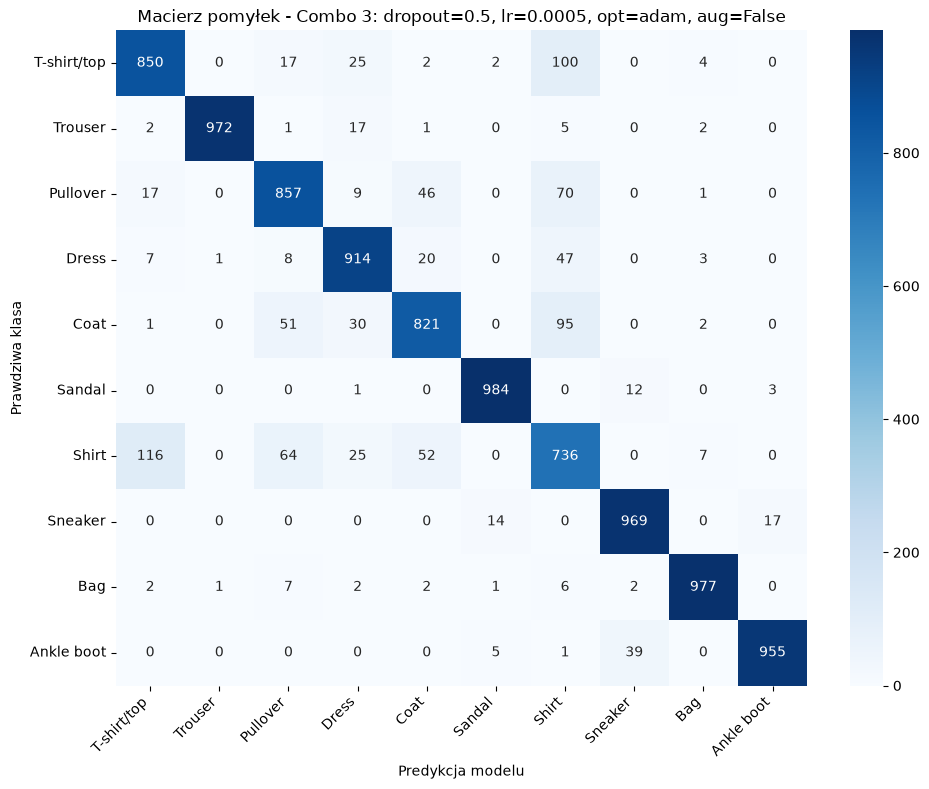

In [63]:
# Macierz pomyłek pokazuje, które klasy model rozpoznaje poprawnie,
# a które najczęściej myli ze sobą.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Macierz pomyłek - {final_model_name}")
plt.xlabel("Predykcja modelu")
plt.ylabel("Prawdziwa klasa")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# WNIOSKI - MAPA POMYŁEK

Na przekątnej macierzy znajdują się największe wartości, co oznacza, że model poprawnie klasyfikuje zdecydowaną większość obrazów. Potwierdza to wysoką skuteczność modelu, wynoszącą około 90,35% accuracy na zbiorze testowym.
Najlepiej rozpoznawane klasy to Trouser (972 poprawnych klasyfikacji), Sandal (984), Sneaker (969), Bag (977) oraz Ankle boot (955). Są to klasy o charakterystycznych cechach wizualnych, dzięki czemu model rzadko je myli z innymi kategoriami.

Największe problemy występują dla klasy Shirt, dla której poprawnie sklasyfikowano jedynie 736 z 1000 obrazów. Koszule są najczęściej błędnie rozpoznawane jako:

T-shirt/top (116 przypadków),
Pullover (64 przypadki),
Coat (52 przypadki).

Wynika to z dużego podobieństwa wizualnego pomiędzy tymi elementami garderoby.

Widoczne są również częste pomyłki pomiędzy:

T-shirt/top → Shirt (100 przypadków),
Coat → Shirt (95 przypadków),
Pullover → Shirt (70 przypadków),
Dress → Shirt (47 przypadków).

Pokazuje to, że klasa Shirt stanowi najtrudniejszą kategorię do jednoznacznego rozpoznania.

Model bardzo dobrze rozróżnia klasy obuwia. Przykładowo:

Sneaker jest sporadycznie mylony z Ankle boot (17 przypadków) oraz Sandal (14 przypadków),
Ankle boot najczęściej mylony jest ze Sneaker (39 przypadków).

Liczba tych pomyłek jest jednak niewielka względem liczby poprawnych klasyfikacji.

Klasa Bag jest rozpoznawana niemal bezbłędnie – jedynie pojedyncze obrazy zostały przypisane do innych klas, co świadczy o wysokiej rozróżnialności tej kategorii.

## METRYKI KAŻDEJ KLASY

In [64]:
# Zamieniamy classification_report na DataFrame,
# żeby łatwiej analizować wyniki dla pojedynczych klas.
# support oznacza ilość przykładów w klasie

report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
T-shirt/top,0.854271,0.8500,0.852130,1000.0000
Trouser,0.997947,0.9720,0.984802,1000.0000
Pullover,0.852736,0.8570,0.854863,1000.0000
Dress,0.893451,0.9140,0.903609,1000.0000
Coat,0.869703,0.8210,0.844650,1000.0000
Sandal,0.978131,0.9840,0.981057,1000.0000
Shirt,0.694340,0.7360,0.714563,1000.0000
Sneaker,0.948141,0.9690,0.958457,1000.0000
Bag,0.980924,0.9770,0.978958,1000.0000
Ankle boot,0.979487,0.9550,0.967089,1000.0000


# WNIOSKI - METRYKI

Model osiągnął 90,35% accuracy na zbiorze testowym, co potwierdza jego wysoką skuteczność w klasyfikacji obrazów ze zbioru Fashion-MNIST.
Wartości macro average (0,9040) oraz weighted average (0,9040) są niemal identyczne. Wynika to z faktu, że zbiór testowy jest zrównoważony (1000 przykładów każdej klasy), a model osiąga stosunkowo wyrównane wyniki dla większości kategorii.

Najlepiej klasyfikowaną klasą okazała się Trouser, dla której uzyskano precision = 0,998, recall = 0,972 oraz F1-score = 0,985. Oznacza to, że model niemal bezbłędnie rozpoznaje spodnie i bardzo rzadko przypisuje do tej klasy inne elementy odzieży.

Bardzo wysokie wyniki osiągnęły również klasy Sandal, Bag, Ankle boot oraz Sneaker, których wartości F1-score przekraczają 0,95. Są to klasy o charakterystycznych cechach wizualnych, dzięki czemu model łatwo je odróżnia od pozostałych kategorii.

Klasa Dress uzyskała również bardzo dobrą skuteczność (F1-score = 0,904), co świadczy o poprawnym rozpoznawaniu większości sukienek.

Największe trudności model miał z klasą Shirt, która osiągnęła najniższy F1-score (0,715). Niska wartość precision (0,694) oznacza, że wiele obrazów innych klas zostało błędnie zakwalifikowanych jako koszule, natomiast recall (0,736) wskazuje, że znaczna część rzeczywistych koszul została przypisana do innych kategorii.

Nieco słabsze wyniki uzyskały również klasy Coat, Pullover oraz T-shirt/top, których wartości F1-score mieszczą się w przedziale 0,84–0,85. Są to elementy odzieży o podobnym wyglądzie, dlatego ich rozróżnienie stanowi większe wyzwanie dla modelu.

## Wykres F1-score dla klas

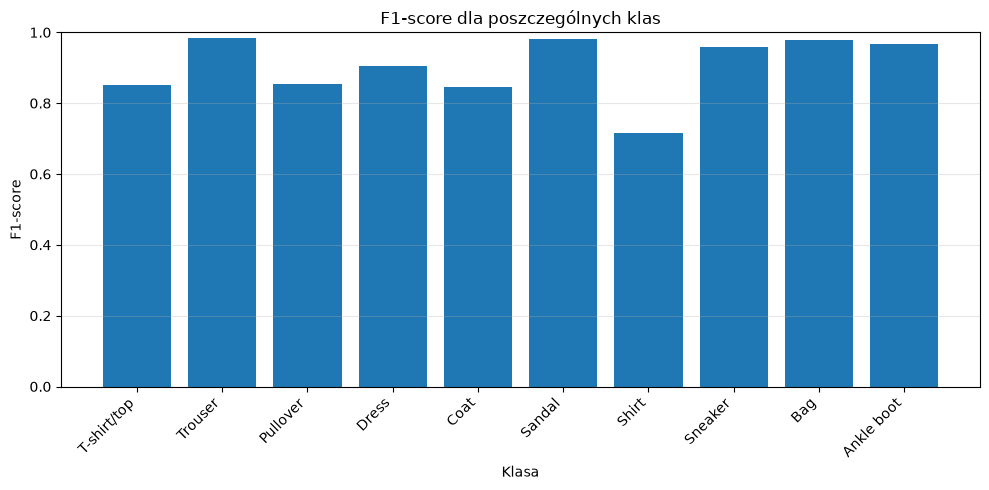

In [65]:
# F1-score łączy precision i recall.
# Dzięki temu dobrze pokazuje, z którymi klasami model radzi sobie najlepiej i najgorzej.

classes_report_df = report_df.iloc[:10].copy()

plt.figure(figsize=(10, 5))

plt.bar(
    classes_report_df.index,
    classes_report_df["f1-score"]
)

plt.title("F1-score dla poszczególnych klas")
plt.xlabel("Klasa")
plt.ylabel("F1-score")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# WNIOSKI F1-SCORE

Wykres pokazuje, że model osiąga bardzo wysokie wartości F1-score dla większości klas, co świadczy o dobrej równowadze pomiędzy precision i recall oraz wysokiej skuteczności klasyfikacji.

Najwyższy F1-score uzyskały klasy:

Trouser (0,985),
Sandal (0,981),
Bag (0,979),
Ankle boot (0,967),
Sneaker (0,958).

Oznacza to, że model bardzo skutecznie rozpoznaje klasy o charakterystycznym wyglądzie i rzadko popełnia błędy w ich klasyfikacji.

Klasa Dress również osiągnęła bardzo dobry wynik (F1-score = 0,904), wskazując na wysoką skuteczność rozpoznawania sukienek.
Średnie wartości F1-score uzyskały klasy T-shirt/top, Pullover oraz Coat (około 0,84–0,85). Wyniki te są nadal dobre, jednak pokazują, że model częściej myli te elementy garderoby z innymi podobnymi klasami.
Najniższy F1-score (0,715) uzyskała klasa Shirt, co potwierdza, że jest ona najtrudniejszą kategorią do rozpoznania. Wynik ten wynika z dużego podobieństwa koszul do innych elementów górnej części odzieży, takich jak T-shirt/top, Pullover oraz Coat.
Rozkład słupków jest zgodny z wcześniejszą analizą raportu klasyfikacji oraz macierzy pomyłek – klasy o wyraźnych cechach wizualnych osiągają najwyższe wyniki, natomiast klasy o podobnym wyglądzie są częściej mylone.

## Analiza błędnych klasyfikacji

In [66]:
# Szukamy indeksów obrazów, które zostały sklasyfikowane błędnie.

wrong_indices = np.where(y_pred != y_test)[0]

print("Liczba błędnych klasyfikacji:", len(wrong_indices))
print("Liczba wszystkich przykładów testowych:", len(y_test))
print(f"Odsetek błędów: {len(wrong_indices) / len(y_test):.4f}")

Liczba błędnych klasyfikacji: 965
Liczba wszystkich przykładów testowych: 10000
Odsetek błędów: 0.0965


## Przykładowe błędne klasyfikacje

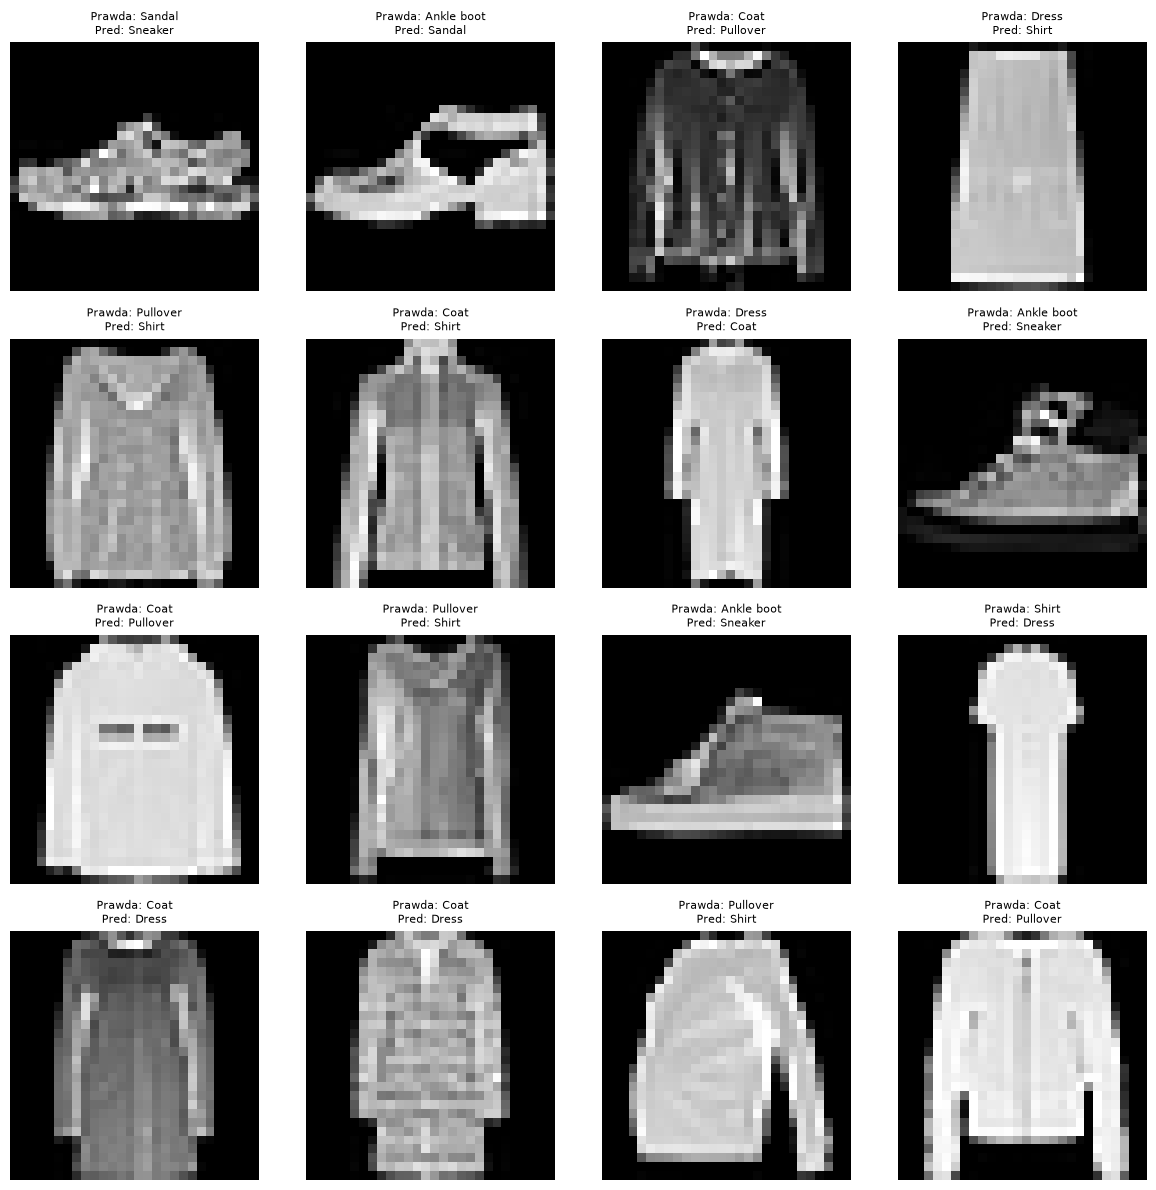

In [67]:
# Przykładowe błędy modelu.
# Pozwala to zobaczyć, czy pomyłki są zrozumiałe wizualnie.

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):

    plt.subplot(4, 4, i + 1)

    plt.imshow(X_test[idx], cmap="gray")

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred[idx]]

    plt.title(
        f"Prawda: {true_label}\nPred: {predicted_label}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Najczęściej mylone klasy

In [68]:

# Tworzymy kopię macierzy pomyłek.
# Na przekątnej znajdują się poprawne klasyfikacje,
# dlatego ustawiamy je na 0, aby analizować tylko błędy modelu.

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)


# Lista, w której zapiszemy wszystkie błędne klasyfikacje.
mistakes = []


# Przechodzimy po wszystkich parach:
# prawdziwa klasa to klasa przewidziana przez model.
for true_class in range(len(class_names)):

    for predicted_class in range(len(class_names)):

        count = cm_errors[true_class, predicted_class]

        # Zapisujemy tylko te przypadki, w których wystąpiła pomyłka.
        if count > 0:

            mistakes.append({
                "Prawdziwa klasa": class_names[true_class],
                "Predykcja modelu": class_names[predicted_class],
                "Liczba pomyłek": count
            })


# Zamieniamy listę pomyłek na DataFrame.
mistakes_df = pd.DataFrame(mistakes)


# Sortujemy pomyłki od najczęstszych do najrzadszych.
mistakes_df = mistakes_df.sort_values(
    by="Liczba pomyłek",
    ascending=False
)


# Resetujemy indeks, żeby tabela była uporządkowana od 0.
mistakes_df = mistakes_df.reset_index(drop=True)


# Wybieramy 10 najczęstszych pomyłek.
top_mistakes = mistakes_df.head(10).copy()


# Ustawiamy indeks od 1, żeby pełnił funkcję rankingu.
top_mistakes.index = range(1, len(top_mistakes) + 1)

top_mistakes

,Prawdziwa klasa,Predykcja modelu,Liczba pomyłek
1,Shirt,T-shirt/top,116
2,T-shirt/top,Shirt,100
3,Coat,Shirt,95
4,Pullover,Shirt,70
5,Shirt,Pullover,64
6,Shirt,Coat,52
7,Coat,Pullover,51
8,Dress,Shirt,47
9,Pullover,Coat,46
10,Ankle boot,Sneaker,39


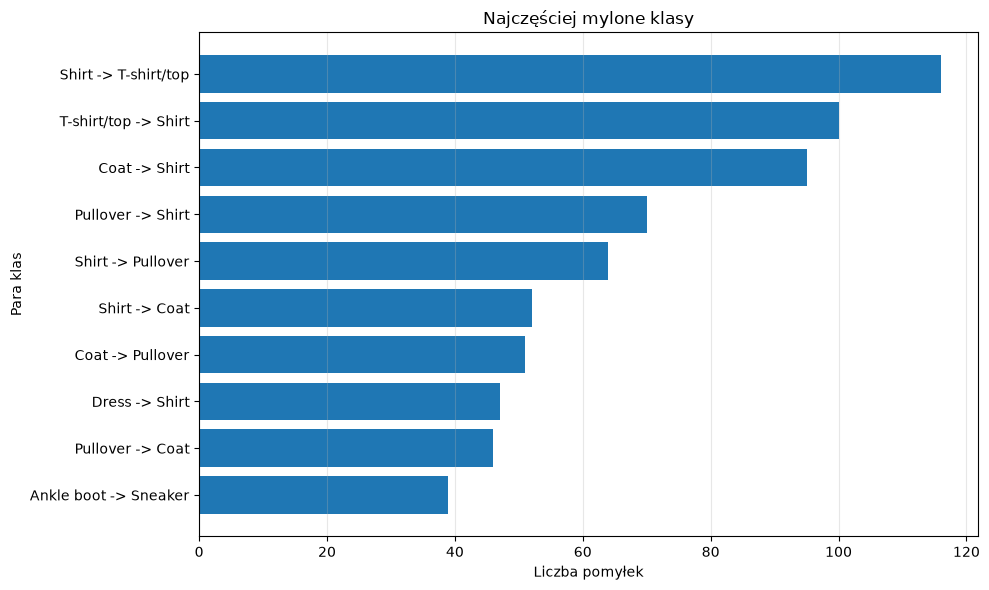

In [69]:
# Tworzymy etykietę pokazującą kierunek pomyłki:
# prawdziwa klasa to predykcja modelu.

top_mistakes_plot = top_mistakes.copy()

top_mistakes_plot["Para klas"] = (
    top_mistakes_plot["Prawdziwa klasa"]
    + " -> "
    + top_mistakes_plot["Predykcja modelu"]
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_mistakes_plot["Para klas"],
    top_mistakes_plot["Liczba pomyłek"]
)

plt.title("Najczęściej mylone klasy")
plt.xlabel("Liczba pomyłek")
plt.ylabel("Para klas")

# Najczęstsza pomyłka na górze.
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# WNIOSKI - RANKING NAJCZĘŚCIEJ MYLONYCH KLAS

Najczęściej występujące błędy dotyczą górnych elementów odzieży, takich jak Shirt, T-shirt/top, Pullover oraz Coat. Klasy te mają podobny kształt, długość rękawów i zbliżoną sylwetkę, dlatego ich rozróżnienie stanowi największe wyzwanie dla modelu.

Najczęściej popełnianym błędem było zakwalifikowanie klasy Shirt jako T-shirt/top (116 przypadków). Świadczy to o dużym podobieństwie wizualnym pomiędzy tymi kategoriami.

Drugim najczęstszym błędem było przypisanie T-shirt/top do klasy Shirt (100 przypadków). Oznacza to, że pomyłki pomiędzy tymi klasami są dwukierunkowe, co potwierdza ich bardzo podobny wygląd na obrazach Fashion-MNIST.

Klasa Shirt była również często mylona z Pullover (64 przypadki) oraz Coat (52 przypadki). Jednocześnie obrazy klas Coat i Pullover były wielokrotnie błędnie klasyfikowane jako Shirt (odpowiednio 95 i 70 przypadków). Pokazuje to, że Shirt stanowi centralną klasę, z którą model najczęściej myli inne elementy górnej części garderoby.

Widoczne są także częste pomyłki pomiędzy Coat i Pullover (51 oraz 46 przypadków), co wynika z podobnego kroju i wyglądu tych ubrań.

Jedyną istotniejszą pomyłką spośród klas obuwia było zakwalifikowanie Ankle boot jako Sneaker (39 przypadków). Liczba ta jest jednak znacznie mniejsza niż w przypadku klas odzieży, co świadczy o dobrej rozróżnialności obuwia.